# การวิเคราะห์อนุกรมเวลาและแบบจำลองพยากรณ์ "อายุใช้งานที่เหลือ" (RUL) ของดอกกัด

**รายวิชา:** การวิเคราะห์อนุกรมเวลาและแบบจำลองการพยากรณ์ (อ.สหพงศ์)
**ชุดข้อมูล:** *Multivariate time series data of milling processes with varying tool wear and machine tools* (LUH, Denkena et al., 2023 — Mendeley Data, DOI 10.17632/zpxs87bjt8)

Notebook นี้เรียงตามหัวข้อการประเมิน 6 ข้อ: (1) ภาพรวม (2) EDA (3) การเตรียมข้อมูล (4) เปรียบเทียบแบบจำลอง (5) วิเคราะห์และสรุปผล (6) การนำไปใช้งาน

ไฟล์ประกอบ: `extract_run_features.py` (สกัดฟีเจอร์จาก .h5) · `rul_runtime.py` (ส่วนใช้งานจริง: ตัวกรอง outlier แบบ causal, ฟีเจอร์รายรัน, GRU แบบ numpy, ข้อจำกัดฟิสิกส์) · `rul_ts.py` (label, ชุดฝึก, GRU) · `experiments_rul.py` (โปรโตคอลประเมินทั้งหมด + ส่งออกแบบจำลอง) · `wear_ts.py` (การวิเคราะห์รายชั้น + แบบจำลอง StateSpace ที่ใช้เปรียบเทียบ)

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings("ignore")

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
import wear_ts as W
import rul_ts as R
import rul_runtime as RT
import experiments_rul as X

DATA_DIR = (HERE.parents[1] / "dataset" / "Multivariate time series data of milling processes with varying tool wear and machine tools"
            / "Multivariate time series data of milling processes with varying tool wear and machine tools")
FIG, RES, MOD = HERE / "figures", HERE / "results_rul", HERE / "models"
for p in (FIG, RES, MOD): p.mkdir(exist_ok=True)
RUN_EXPERIMENTS = False      # True = รัน experiments_rul.main() ใหม่ทั้งหมด (~5 นาทีบน GPU) แทนการอ่านผลที่บันทึกไว้

# ---- สไตล์กราฟ ----
C = dict(blue="#2a78d6", orange="#eb6834", aqua="#1baf7a", yellow="#eda100", violet="#4a3aa7", red="#e34948",
         ink="#0b0b0b", ink2="#52514e", muted="#8a8984", grid="#e4e3df", surface="#fcfcfb", band="#cde2fb")
MACHINE_COLOR = {1: C["blue"], 2: C["orange"], 3: C["aqua"]}
MODEL_COLOR = {"GRU[full]": C["blue"], "StateSpace": C["orange"], "Fleet": C["muted"],
               "GRU[time+machine]": C["aqua"], "GRU[sensors+time]": C["violet"]}
MODEL_NAME = {"GRU[full]": "GRU direct-RUL (เซนเซอร์+เวลา+เครื่อง)", "StateSpace": "StateSpace (VB แฝง → จุดตัดเกณฑ์)",
              "Fleet": "Fleet reference (อายุเฉลี่ยของเครื่อง)", "GRU[time+machine]": "GRU ไม่มีเซนเซอร์",
              "GRU[sensors+time]": "GRU ไม่ระบุเครื่อง"}
plt.rcParams.update({
    "font.family": ["Leelawadee UI", "DejaVu Sans"], "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.facecolor": C["surface"], "figure.facecolor": "white", "axes.edgecolor": C["muted"],
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": C["grid"],
    "grid.linewidth": 0.6, "lines.linewidth": 1.8, "legend.frameon": False, "axes.labelcolor": C["ink2"],
    "xtick.color": C["ink2"], "ytick.color": C["ink2"], "axes.axisbelow": True})
def savefig(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")
pd.set_option("display.width", 200, "display.max_columns", 30)
print("พร้อม:", DATA_DIR.exists())

พร้อม: True


---
# 1. ภาพรวมของโครงงาน

**ปัญหา:** คมตัดของดอกกัด (end mill) สึกหรอสะสมตลอดการใช้งาน วัดด้วยความกว้างรอยสึกด้านข้าง (**flank wear, VB**) ตามนิยามใน ISO 8688-2 การเปลี่ยนดอก *เร็วเกินไป* ทิ้งอายุดอกและหยุดเครื่องบ่อย ส่วน *ช้าเกินไป* ทำให้ผิวงานเสีย ขนาดเพี้ยน หรือดอกแตก

**สิ่งที่ต้องการรู้ระหว่างผลิต** ไม่ใช่ค่า VB แต่คือ **"ดอกนี้ยังใช้ได้อีกนานเท่าไร" = อายุใช้งานที่เหลือ (Remaining Useful Life, RUL)** โครงงานนี้จึงสร้างแบบจำลองอนุกรมเวลาที่ **พยากรณ์ RUL โดยตรง** จากข้อมูลที่เครื่องบันทึกเองทุกแนวตัด:
- อินพุต: **เวลาตัดสะสม + ค่าเฉลี่ยรายรันของแรงบิด spindle, แรง/แรงบิดมอเตอร์แกนป้อน X/Y, แรงตัด Fx/Fy/Fz/แรงลัพธ์ + หมายเลขเครื่อง + ตำแหน่งแนวตัด** — **ไม่มี VB** (ต้องถอดดอกไปส่องกล้อง โรงงานไม่วัดระหว่างผลิต)
- เป้าหมาย (label จาก VB ของดอกเก่าที่ใช้จนหมดอายุ): เวลาตัดที่เหลือจนถึง **เกณฑ์หมดอายุ VB = 140 µm** และจนถึง **จุดเริ่มสึกเร่ง VB = 103 µm**
- เอาต์พุตเพื่อการตัดสินใจ: RUL + ช่วง P10–P90 → สถานะ STEADY / ACCELERATED / END_OF_LIFE → คำแนะนำ OK / WATCH / PLAN_REPLACEMENT / REPLACE_NOW

**เกณฑ์อายุดอก:** ISO 8688-2 ใช้รอยสึกด้านข้าง VB เป็นเกณฑ์อายุดอกกัดหลัก และให้กำหนดค่าเกณฑ์ตามงาน (ค่าที่ใช้ทั่วไปในงานกัดหยาบคือ VB ≈ 0.3 mm งานเก็บผิวใช้ต่ำกว่านั้น) ในชุดข้อมูลนี้ผู้ทดลองหยุดใช้ดอกที่ VB ≈ 150 µm จึงกำหนด **เกณฑ์เฉพาะงาน 140 µm** (ทุกดอกผ่านจริง) ส่วน **103 µm** มาจากการวิเคราะห์ข้อมูลในหัวข้อ 3.6 (จุดเปลี่ยนระบอบของอัตราสึก = เริ่มช่วงสึกเร่งของเส้นโค้งการสึก 3 ช่วง)

**ชุดข้อมูล (LUH milling):** ดอกคาร์ไบด์ 4 คม 9 ดอก บนเครื่อง 5 แกน 3 เครื่อง (M1: T1–T3, M2: T4–T6, M3: T7–T9) กัดบ่าเหล็กหล่อจากดอกใหม่จนหมดอายุ รวม **6,418 ไฟล์ .h5** (1 ไฟล์ = กัด 1 แนว ≈ 4.4 วินาที) แรงตัดจาก dynamometer 25 kHz และสัญญาณ controller 500 Hz

**ข้อกำหนดของระบบ:** ดอก T3, T6, T9 (เครื่องละ 1 ดอก) ถูก **สงวนไว้ไม่ใช้ฝึกแบบจำลองที่ใช้งานจริง** เพื่อนำไปสตรีมบนเว็บตามเวลาจริง แบบจำลองเก็บใน MinIO และหน้าเว็บไม่แสดงค่า VB/RUL จริงจนกว่าดอกจะถูกถอด (ไม่สปอยข้อมูล)

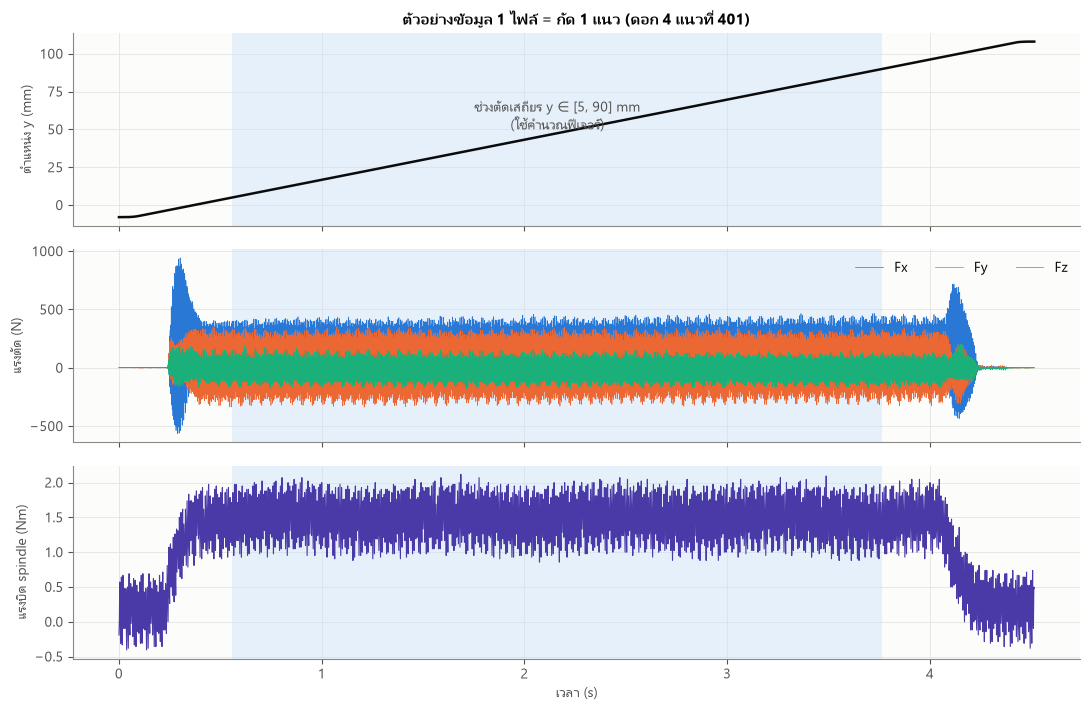

In [2]:
import h5py
fl = pd.read_csv(DATA_DIR / "filelist.csv")
rec = fl[fl.tool == 4].sort_values("run").iloc[400]
with h5py.File(DATA_DIR / rec.filename, "r") as f:
    ts = f["signals_sensor/time_sensor"][0]; F = {a: f[f"signals_sensor/force_sensor_{a}"][0] for a in "xyz"}
    tm = f["signals_machine/time_machine"][0]; ypos = f["signals_machine/tool_position_y"][0]
    sp = f["signals_machine/torque_spindle"][0]
yi = np.interp(ts, tm, ypos); stable = (yi >= 5) & (yi <= 90)
t0, t1 = ts[stable][0], ts[stable][-1]
fig, ax = plt.subplots(3, 1, figsize=(11, 7.2), sharex=True)
ax[0].plot(tm, ypos, color=C["ink"]); ax[0].set_ylabel("ตำแหน่ง y (mm)")
ax[0].set_title(f"ตัวอย่างข้อมูล 1 ไฟล์ = กัด 1 แนว (ดอก 4 แนวที่ {rec.run})")
for i, a in enumerate("xyz"):
    ax[1].plot(ts[::10], F[a][::10], lw=0.5, color=[C["blue"], C["orange"], C["aqua"]][i], label=f"F{a}")
ax[1].set_ylabel("แรงตัด (N)"); ax[1].legend(ncol=3, loc="upper right")
ax[2].plot(tm, sp, color=C["violet"], lw=0.8); ax[2].set_ylabel("แรงบิด spindle (Nm)"); ax[2].set_xlabel("เวลา (s)")
for a_ in ax: a_.axvspan(t0, t1, color=C["band"], alpha=0.45, lw=0)
ax[0].text((t0 + t1) / 2, 50, "ช่วงตัดเสถียร y ∈ [5, 90] mm\n(ใช้คำนวณฟีเจอร์)", ha="center", color=C["ink2"])
fig.tight_layout(); savefig(fig, "01_run_signals"); plt.show()

---
# 2. การวิเคราะห์ข้อมูลเบื้องต้น (EDA)

ไฟล์ .h5 ทั้ง 6,418 ไฟล์ (≈10 GB) ถูกย่อเป็นตาราง **1 แถวต่อ 1 แนวตัด** ด้วย `extract_run_features.py` ซึ่งคำนวณสถิติของสัญญาณใน *ช่วงตัดเสถียร* (mean, RMS, std, ช่วง p0.5–p99.5 ของ Fx, Fy, Fz, แรงลัพธ์ และแรงบิด spindle) พร้อมตัวชี้วัดคุณภาพข้อมูล (NaN, สัดส่วนสัญญาณแบน, ความยาวสัญญาณ)
- รวมสัญญาณแกนป้อนจาก controller ด้วย: M1 เป็นบอลสกรู (`torque_axis_*`, Nm) ส่วน M2/M3 เป็น linear direct drive (`force_axis_*`, N) — หน่วยต่างกัน จึงใช้เป็น *% การเปลี่ยนแปลงจากค่าตั้งต้นของดอกเดียวกัน*

## 2.1 สถิติเชิงพรรณนา (Descriptive Statistics)

In [3]:
runs_raw = W.assign_layers(pd.read_csv(HERE / "run_features.csv"))
runs_raw["contact_min"] = runs_raw["contact"] / 60
inv = runs_raw.groupby("tool").agg(machine=("machine", "first"), n_runs=("run", "size"), n_layers=("layer", "nunique"),
                                   first_layer=("layer", "min"), last_layer=("layer", "max"), VB_start=("wear", "first"),
                                   VB_end=("wear", "last"), contact_end_min=("contact_min", "last"))
inv["layer_reach_140"] = [int(g.loc[g.wear >= 140, "layer"].min()) for _, g in runs_raw.groupby("tool")]
print("สรุปรายดอก"); display(inv.round(1))
cols = {"wear": "VB (µm)", "contact_min": "เวลาตัดสะสม (นาที)", "axy_absmean": "แกนป้อน y |mean| (controller)", "axx_absmean": "แกนป้อน x |mean| (controller)", "fx_mean": "Fx mean (N)", "fy_mean": "Fy mean (N)",
        "fz_mean": "Fz mean (N)", "fres_mean": "|F| mean (N)", "sp_rms": "Spindle torque RMS (Nm)"}
desc = runs_raw[list(cols)].describe().T.rename(index=cols)
desc["skew"] = runs_raw[list(cols)].skew().values
print("สถิติเชิงพรรณนาระดับแนวตัด (n = 6,418)"); display(desc.round(2))

สรุปรายดอก


,machine,n_runs,n_layers,first_layer,last_layer,VB_start,VB_end,contact_end_min,layer_reach_140
tool,,,,,,,,,
1,1,609,21,1,21,3,158,57.6,20
2,1,609,21,1,21,3,145,57.0,21
3,1,638,22,1,22,3,152,60.8,21
4,2,928,32,1,32,3,149,86.2,31
5,2,928,32,1,32,3,148,86.2,31
6,2,928,32,1,32,3,147,86.4,32
7,3,609,21,1,21,3,153,57.3,20
8,3,560,20,2,21,34,150,57.9,20
9,3,609,21,1,21,3,160,57.5,20


สถิติเชิงพรรณนาระดับแนวตัด (n = 6,418)


,count,mean,std,min,25%,50%,75%,max,skew
VB (µm),6418.0,81.34,30.15,3.00,58.00,79.00,100.00,160.00,0.36
เวลาตัดสะสม (นาที),6418.0,35.41,21.74,0.18,17.42,34.13,50.88,86.35,0.35
แกนป้อน y |mean| (controller),6418.0,238.63,225.10,1.04,1.50,129.56,450.92,748.03,0.38
แกนป้อน x |mean| (controller),6418.0,259.34,183.71,0.60,1.41,303.84,399.77,690.40,-0.30
Fx mean (N),6418.0,318.11,91.01,144.38,236.42,307.87,394.88,564.65,0.31
Fy mean (N),6418.0,64.31,62.39,-21.78,8.57,51.52,111.22,262.44,0.62
Fz mean (N),6418.0,-7.59,22.92,-80.90,-25.52,-1.88,11.84,30.10,-0.61
|F| mean (N),6418.0,385.16,110.72,163.28,293.73,371.58,468.07,706.72,0.33
Spindle torque RMS (Nm),6418.0,1.39,0.20,0.96,1.23,1.39,1.54,1.86,0.07


In [4]:
# ตัวแปรเซนเซอร์ใดสะท้อนการสึกหรอ: Spearman ρ กับ VB แยกรายดอก (ข้อมูลแต่ละเครื่องมีระดับแรงต่างกัน จึงต้องดูรายดอก)
hi_cols = ["sp_rms", "axy_absmean", "axx_absmean", "fx_mean", "fy_mean", "fz_mean", "fres_mean", "pcdy_std", "fx_std", "fy_std", "fres_tooth_amp"]
rho = pd.DataFrame({t: {c: stats.spearmanr(g[c], g.wear)[0] for c in hi_cols} for t, g in runs_raw.groupby("tool")})
rho.columns = [f"T{t}" for t in rho.columns]
rho["|ρ| ต่ำสุด"] = rho.abs().min(axis=1)
display(rho.sort_values("|ρ| ต่ำสุด", ascending=False).round(2))

,T1,T2,T3,T4,T5,T6,T7,T8,T9,|ρ| ต่ำสุด
fy_mean,1.00,1.00,0.99,1.00,1.00,1.00,1.00,0.99,1.00,0.99
fx_mean,0.98,0.99,0.99,1.00,0.99,1.00,1.00,0.99,0.99,0.98
axy_absmean,1.00,1.00,0.99,0.99,0.99,0.99,0.99,0.97,0.99,0.97
sp_rms,0.97,0.99,0.98,1.00,0.99,1.00,0.99,0.97,0.98,0.97
fz_mean,-0.98,-0.99,-0.99,-0.99,-0.96,-0.99,-0.98,-0.99,-0.99,0.96
fres_mean,0.98,0.99,0.99,1.00,0.99,1.00,0.94,0.84,0.96,0.84
axx_absmean,0.94,0.94,0.92,0.90,0.88,0.89,0.85,0.82,0.80,0.80
fy_std,0.99,0.98,0.97,1.00,0.99,1.00,0.58,0.59,0.92,0.58
fres_tooth_amp,-0.35,-0.12,0.19,-0.38,-0.50,-0.48,-0.29,0.26,-0.67,0.12
pcdy_std,0.92,0.92,-0.10,1.00,1.00,1.00,0.99,0.98,0.95,0.10


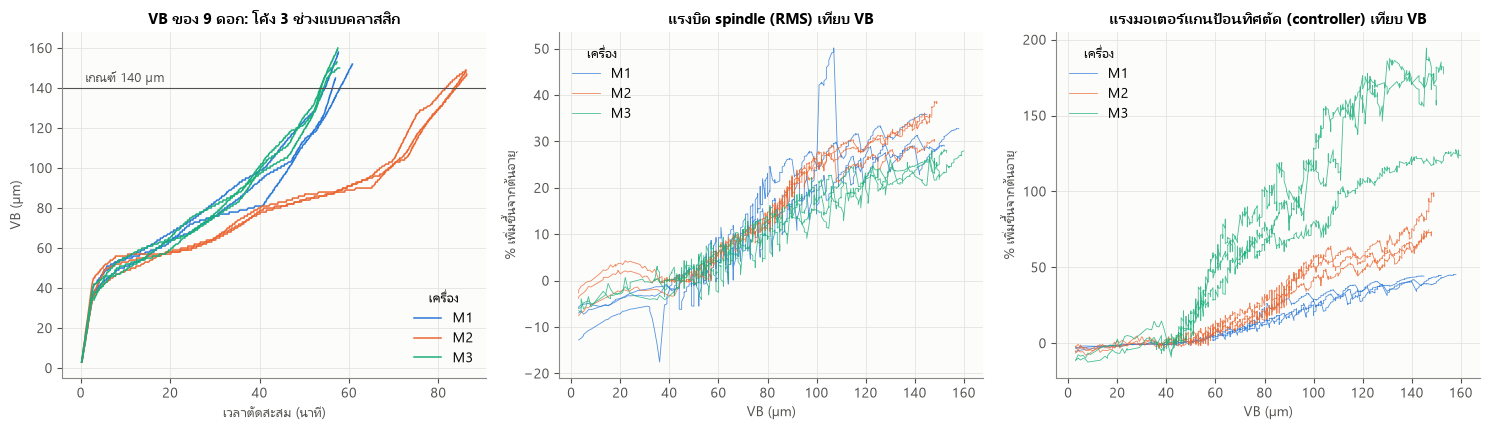

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
for t, g in runs_raw.groupby("tool"):
    m = int(g.machine.iloc[0])
    ax[0].plot(g.contact_min, g.wear, color=MACHINE_COLOR[m], lw=1.1, label=f"M{m}" if t in (1, 4, 7) else None)
ax[0].axhline(W.VB_LIMIT, color=C["ink2"], lw=0.8); ax[0].text(1, W.VB_LIMIT + 3, "เกณฑ์ 140 µm", color=C["ink2"], fontsize=9)
ax[0].set(xlabel="เวลาตัดสะสม (นาที)", ylabel="VB (µm)", title="VB ของ 9 ดอก: โค้ง 3 ช่วงแบบคลาสสิก"); ax[0].legend(title="เครื่อง")
base = {}
for t, g in runs_raw.groupby("tool"):
    m = int(g.machine.iloc[0]); ref = g[g.layer == g.layer[g.layer >= 2].min()]
    for k, c in enumerate(["sp_rms", "axy_absmean"]):
        rel = g[c] / ref[c].median() - 1
        ax[k + 1].plot(g.wear, rel * 100, color=MACHINE_COLOR[m], lw=0.6, alpha=0.8, label=f"M{m}" if t in (1, 4, 7) else None)
ax[1].set(xlabel="VB (µm)", ylabel="% เพิ่มขึ้นจากต้นอายุ", title="แรงบิด spindle (RMS) เทียบ VB")
ax[2].set(xlabel="VB (µm)", ylabel="% เพิ่มขึ้นจากต้นอายุ", title="แรงมอเตอร์แกนป้อนทิศตัด (controller) เทียบ VB")
ax[1].legend(title="เครื่อง"); ax[2].legend(title="เครื่อง")
fig.tight_layout(); savefig(fig, "02_overview"); plt.show()

**อ่านผล 2.1**
- VB ของทุกดอกเป็นโค้งการสึก **3 ช่วงแบบคลาสสิก**: สึกเร็วช่วงแรก (break-in, ชั้นแรก VB 0 → ~40 µm) → สึกคงที่ (steady) → **สึกเร่ง** ช่วงท้าย
- เครื่อง M2 (T4–T6) อายุยาวกว่ามาก (≈ 31 ชั้น เทียบ ≈ 20 ชั้น) แม้ใช้พารามิเตอร์ตัดเดียวกัน → *ผลของเครื่องจักร* เป็นแหล่งความแปรปรวนหลัก
- ค่าเฉลี่ยแรงตัด (Fx, Fy, Fz), แรงบิด spindle และ **แรงมอเตอร์แกนป้อนทิศตัด (`axy`, จาก controller)** เพิ่มขึ้นตาม VB อย่างเป็นเอกภาพ (|ρ| ≥ 0.96 ทุกดอก) และเมื่อคิดเป็น *% เพิ่มขึ้นจากต้นอายุของดอกนั้น* เส้นของ 3 เครื่องซ้อนกัน → ใช้เป็น health indicator แบบสัมพัทธ์ได้ ส่วน std/peak ของแรงสัมพันธ์กับ VB ไม่สม่ำเสมอระหว่างเครื่อง จึงไม่ใช้

## 2.2 ข้อมูลสูญหาย (Missing Values) — ตรวจ 3 ระดับ

In [6]:
feat_cols = [c for c in runs_raw.columns if c.startswith(("fx_", "fy_", "fz_", "fres_", "sp_"))]
runs_per_tool = runs_raw.groupby("tool").run.agg(["min", "max", "size"])
missing = pd.Series({
    "จำนวนไฟล์ (แนวตัด)": len(runs_raw),
    "ไฟล์ที่อ่านไม่ได้ / error": int(runs_raw["error"].notna().sum()) if "error" in runs_raw else 0,
    "NaN ในสัญญาณดิบทุกไฟล์ (จุด)": int(runs_raw.nan_count.sum()),
    "ค่าว่างในตารางฟีเจอร์": int(runs_raw[feat_cols].isna().sum().sum()),
    "label VB: filelist ≠ ไฟล์ .h5": int((runs_raw.wear != runs_raw.wear_h5).sum()),
    "เวลาตัดสะสม: filelist ≠ .h5": int((abs(runs_raw.contact - runs_raw.contact_h5) > 0.5).sum()),
    "แถวซ้ำ (tool, run)": int(runs_raw.duplicated(["tool", "run"]).sum()),
    "ดอกที่เลข run ไม่ต่อเนื่อง": int((runs_per_tool["max"] - runs_per_tool["min"] + 1 != runs_per_tool["size"]).sum()),
    "ความยาวไฟล์ (วินาที) ต่ำสุด–สูงสุด": f"{runs_raw.duration_s.min():.2f}–{runs_raw.duration_s.max():.2f}",
    "ความยาวช่วงตัดเสถียร (วินาที)": f"{runs_raw.seg_s.min():.2f}–{runs_raw.seg_s.max():.2f}",
    "สัดส่วนสัญญาณแบนสูงสุด": round(runs_raw.flat_frac.max(), 3),
}, dtype=object)
display(missing.to_frame("ผลตรวจ"))
# ระดับ "โครงสร้างการทดลอง": 1 ชั้น = 44 แนว แต่ถูกบันทึกไว้กี่แนว
per_layer = runs_raw.groupby(["tool", "layer"]).size()
print("จำนวนแนวที่บันทึกต่อชั้น:", per_layer.value_counts().to_dict())
print("ชั้นที่ไม่ครบ:", per_layer[per_layer != W.LAYER_RUNS].to_dict())
print("ดอก 8: แนวแรกมีเวลาตัดสะสม", runs_raw[runs_raw.tool == 8].contact.iloc[0], "วินาที (ดอกอื่นเริ่มที่ 11 วินาที)")

,ผลตรวจ
จำนวนไฟล์ (แนวตัด),6418
ไฟล์ที่อ่านไม่ได้ / error,0
NaN ในสัญญาณดิบทุกไฟล์ (จุด),0
ค่าว่างในตารางฟีเจอร์,0
label VB: filelist ≠ ไฟล์ .h5,0
เวลาตัดสะสม: filelist ≠ .h5,0
"แถวซ้ำ (tool, run)",0
ดอกที่เลข run ไม่ต่อเนื่อง,0
ความยาวไฟล์ (วินาที) ต่ำสุด–สูงสุด,4.41–4.52
ความยาวช่วงตัดเสถียร (วินาที),3.18–3.23


จำนวนแนวที่บันทึกต่อชั้น: {29: 221, 9: 1}
ชั้นที่ไม่ครบ: {(8, 2): 9}
ดอก 8: แนวแรกมีเวลาตัดสะสม 177 วินาที (ดอกอื่นเริ่มที่ 11 วินาที)


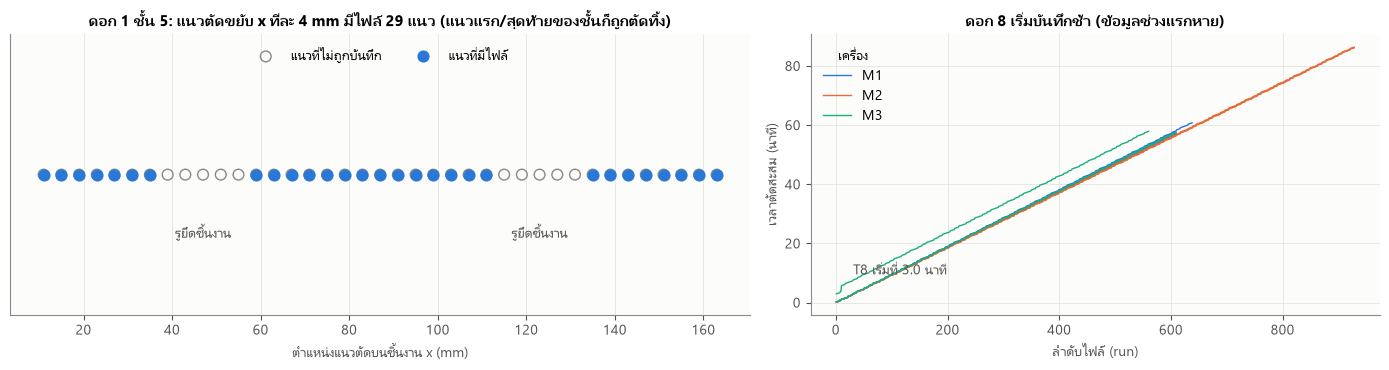

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})
g = runs_raw[(runs_raw.tool == 1) & (runs_raw.layer == 5)]
present = np.round(g.x_pos.values).astype(int)
all_x = np.arange(11, 164, 4)          # แนวตัดช่วง x = 11–163 mm ห่างกัน 4 mm
ax[0].scatter(all_x, np.zeros_like(all_x), s=60, facecolors="none", edgecolors=C["muted"], label="แนวที่ไม่ถูกบันทึก")
ax[0].scatter(present, np.zeros_like(present), s=60, color=C["blue"], label="แนวที่มีไฟล์")
ax[0].set_yticks([]); ax[0].set_xlabel("ตำแหน่งแนวตัดบนชิ้นงาน x (mm)"); ax[0].legend(loc="upper center", ncol=2)
ax[0].set_title("ดอก 1 ชั้น 5: แนวตัดขยับ x ทีละ 4 mm มีไฟล์ 29 แนว (แนวแรก/สุดท้ายของชั้นก็ถูกตัดทิ้ง)"); ax[0].set_ylim(-1, 1)
ax[0].text(47, -0.45, "รูยึดชิ้นงาน", ha="center", color=C["ink2"]); ax[0].text(123, -0.45, "รูยึดชิ้นงาน", ha="center", color=C["ink2"])
for t, gg in runs_raw.groupby("tool"):
    m = int(gg.machine.iloc[0]); ax[1].plot(gg.run, gg.contact_min, color=MACHINE_COLOR[m], lw=1, label=f"M{m}" if t in (1, 4, 7) else None)
ax[1].set(xlabel="ลำดับไฟล์ (run)", ylabel="เวลาตัดสะสม (นาที)", title="ดอก 8 เริ่มบันทึกช้า (ข้อมูลช่วงแรกหาย)")
g8 = runs_raw[runs_raw.tool == 8]; ax[1].annotate(f"T8 เริ่มที่ {g8.contact_min.iloc[0]:.1f} นาที", (g8.run.iloc[0], g8.contact_min.iloc[0]), xytext=(12, 14), textcoords="offset points", color=C["ink2"])
ax[1].legend(title="เครื่อง"); fig.tight_layout(); savefig(fig, "03_missing_structure"); plt.show()

**อ่านผลและวิธีจัดการ 2.2**
| ระดับ | สิ่งที่พบ | วิธีจัดการ |
|---|---|---|
| ค่าในไฟล์/ตาราง | ไม่มี NaN, ไม่มีไฟล์เสีย, label สองแหล่งตรงกัน, ไม่มีแถวซ้ำ, เลข run ต่อเนื่อง | ไม่ต้อง impute |
| ความยาวสัญญาณ | ความยาวไฟล์ต่างกันเล็กน้อยตามเครื่อง (4.41–4.52 s) | คำนวณฟีเจอร์เฉพาะช่วงตัดเสถียรตามตำแหน่ง y ซึ่งยาวเท่ากันทุกไฟล์ (~3.2 s) จึงเทียบกันได้ |
| โครงสร้างการทดลอง | ทุกชั้นบันทึก 29/44 แนวเท่ากัน (แนวแรก/สุดท้ายของชั้น และแนวทับรูยึดชิ้นงานถูกตัดทิ้งโดยผู้จัดทำ) จึงเห็นเวลาตัดสะสมกระโดดเป็นจังหวะ 7–14–8 แนว | **ไม่ใช้ลำดับไฟล์เป็นแกนเวลา** (แนวที่หายก็สึกหรอจริง) แกนเวลาของแบบจำลอง = **เวลาตัดสะสม** ซึ่งนับแนวที่ไม่ถูกบันทึกแล้ว; วิเคราะห์ VB ที่ความถี่ของการวัดจริง (รายชั้น ≈164 s) |
| ข้อมูลหายช่วงต้นอายุ | ดอก 8 ไม่มีชั้นที่ 1 และมีชั้นที่ 2 เพียง 9 แนว (เริ่มที่ VB = 34 µm) | **ไม่สร้างข้อมูลช่วง break-in ขึ้นเอง** (เดาไม่ได้อย่างน่าเชื่อถือ) — แบบจำลองไม่ใช้ช่วง break-in อยู่แล้ว: ค่าตั้งต้นของดอก = 29 รันแรกหลังเวลาตัด 170 วินาที ซึ่งดอก 8 มีครบ (เริ่มที่ 177 วินาที) |
| หน่วย | attribute ใน .h5 ระบุเวลาตัดสะสมเป็น "min" แต่เพิ่มขึ้น 3–4 หน่วยต่อแนวที่ยาว ≈3.2 s และเอกสารต้นทางระบุเป็นวินาที | ใช้หน่วย **วินาที** |

## 2.3 ค่าผิดปกติ (Outliers)

**(ก) VB — ตรวจด้วยกฎทางฟิสิกส์**: VB ต้องไม่ลดลง, อยู่ในช่วงที่เป็นไปได้, และอัตราสึกต่อชั้นไม่กระโดดผิดธรรมชาติ

In [8]:
L_raw = W.layer_table(runs_raw)
dvb = L_raw.sort_values(["tool", "layer"]).groupby("tool").VB.diff()
vb_rules = pd.Series({
    "แนวตัดที่ VB ลดลงจากแนวก่อน": int((runs_raw.sort_values(["tool", "run"]).groupby("tool").wear.diff() < 0).sum()),
    "VB นอกช่วง 0–200 µm": int(((runs_raw.wear < 0) | (runs_raw.wear > 200)).sum()),
    "ΔVB ต่อชั้น สูงสุด (µm)": float(dvb.max()),
    "ชั้นที่ ΔVB > 25 µm (หลังชั้นแรก)": int((dvb[L_raw.layer > 2] > 25).sum()),
})
display(vb_rules.to_frame("ผล"))

,ผล
แนวตัดที่ VB ลดลงจากแนวก่อน,0.0
VB นอกช่วง 0–200 µm,0.0
ΔVB ต่อชั้น สูงสุด (µm),20.0
ชั้นที่ ΔVB > 25 µm (หลังชั้นแรก),0.0


ไม่พบค่า VB ผิดปกติ ΔVB ที่สูงสุดในช่วงท้าย (≈20 µm/ชั้น) เกิดกับทุกดอกในช่วงสึกเร่ง จึงเป็น *พฤติกรรมจริง* ไม่ใช่ outlier — **ไม่ตัดทิ้ง**

**(ข) Health indicator จากเซนเซอร์** — z-score ธรรมดาใช้ไม่ได้ เพราะอนุกรมมีทั้ง trend (การสึก) และรูปแบบฤดูกาลคาบ 29 แนว (หัวข้อ 3.2) และแอมพลิจูดฤดูกาลโตตามระดับ (multiplicative) จึงใช้ขั้นตอน:
1. แปลง **log** ให้ฤดูกาลเป็นแบบบวก → แยก trend + seasonal ด้วย **STL แบบ robust** (คาบ 29)
2. ตีธงเมื่อผิดปกติ *ทั้งเชิงสถิติและเชิงปฏิบัติ*: |robust z ของ residual| > 4 (z = (r − median)/1.4826·MAD) **และ** เบี่ยงจากค่าคาดหมาย > 3% (≈ การเปลี่ยนจากการสึกราว 2 ชั้น — เกณฑ์ z อย่างเดียวตีธงเกิน 10% เพราะสัญญาณเรียบมากจน MAD เล็ก)
3. **แทนด้วยค่า trend + seasonal** ณ จุดนั้น (ไม่ลบแถว เพื่อรักษาตารางเวลา)

In [9]:
runs_clean, flags = W.clean_sensor_outliers(runs_raw)
fl_tab = flags.groupby(runs_raw.tool).sum().T
fl_tab.columns = [f"T{c}" for c in fl_tab.columns]
fl_tab["รวม"] = fl_tab.sum(axis=1); fl_tab["%"] = (fl_tab["รวม"] / len(runs_raw) * 100).round(2)
display(fl_tab)
# outlier แบบกลุ่ม (collective): ชั้นที่ถูกตีธง ≥ 10 แนว
coll = flags.assign(tool=runs_raw.tool, layer=runs_raw.layer).groupby(["tool", "layer"]).sum()
display(coll[(coll >= 10).any(axis=1)])

,T1,T2,T3,T4,T5,T6,T7,T8,T9,รวม,%
sp_rms,33,0,4,4,2,5,2,9,2,61,0.95
axy_absmean,0,0,0,1,2,1,17,16,25,62,0.97
axx_absmean,34,6,8,13,26,6,90,14,15,212,3.30
fx_mean,49,8,11,9,44,8,9,8,12,158,2.46
fres_mean,45,5,8,0,22,5,5,49,68,207,3.23


sp_rms  axy_absmean  axx_absmean  fx_mean  fres_mean
tool layer                                                      
1    15          0            0            0       12         11
     16         29            0           29       21         20
4    1           4            0           11        9          0
5    1           2            0            4       20          5
     27          0            2           10        0          0
     28          0            0            8       24         17
7    8           0            0           17        0          0
     12          0            1           13        0          0
8    3           0            0            3        0         13
     13          0           11            0        0          1
9    14          0            1            0        0         17
     19          0            0            0        0         19

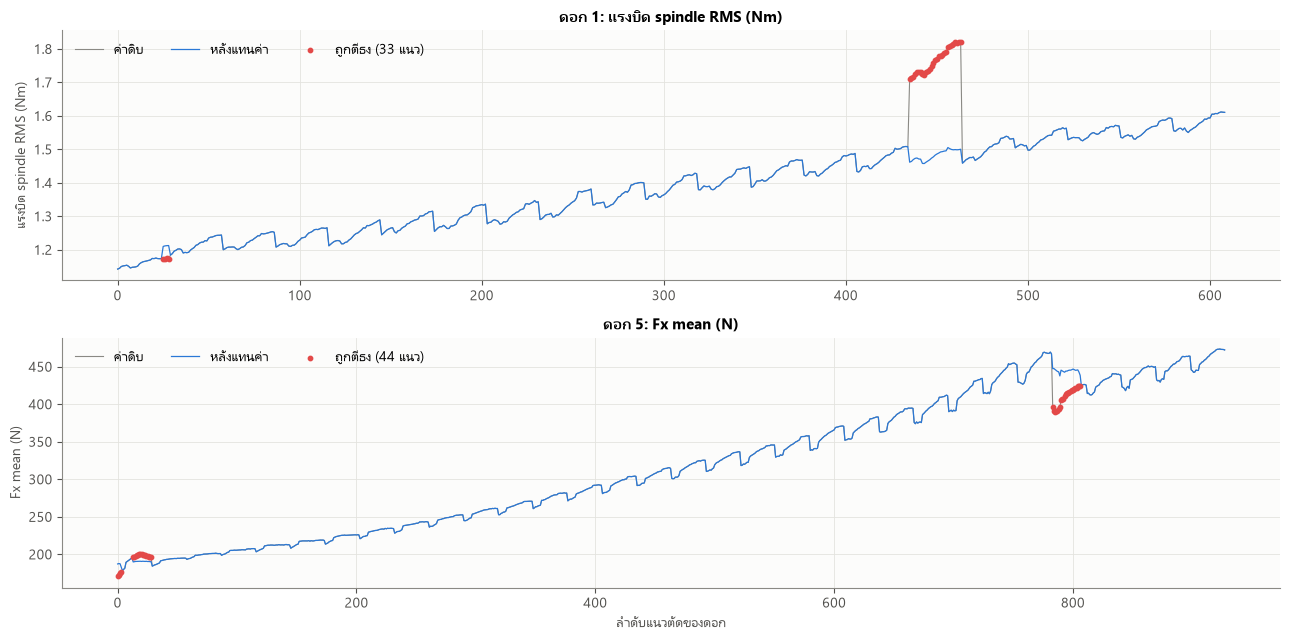

In [10]:
from statsmodels.tsa.seasonal import STL
fig, ax = plt.subplots(2, 1, figsize=(13, 6.5))
for i, (t, col, lab) in enumerate([(1, "sp_rms", "แรงบิด spindle RMS (Nm)"), (5, "fx_mean", "Fx mean (N)")]):
    idx = runs_raw[runs_raw.tool == t].sort_values("run").index
    x = runs_raw.loc[idx, col].values; xc = runs_clean.loc[idx, col].values; b = flags.loc[idx, col].values
    ax[i].plot(x, color=C["muted"], lw=0.8, label="ค่าดิบ")
    ax[i].plot(xc, color=C["blue"], lw=0.9, label="หลังแทนค่า")
    ax[i].scatter(np.where(b)[0], x[b], s=10, color=C["red"], zorder=3, label=f"ถูกตีธง ({b.sum()} แนว)")
    ax[i].set(ylabel=lab, title=f"ดอก {t}: {lab}")
    ax[i].legend(ncol=3, loc="upper left")
ax[1].set_xlabel("ลำดับแนวตัดของดอก")
fig.tight_layout(); savefig(fig, "04_outliers"); plt.show()

**อ่านผล 2.3:** ตีธงเพียง ~1–3% ของแนวตัด ที่เด่นคือ **outlier แบบกลุ่ม** ทั้งชั้น เช่น ดอก 1 ชั้น 16 แรงบิด spindle และ Fx กระโดดขึ้น ~17% ตลอดทั้งชั้นแล้วกลับลงมาเท่าเดิม ขณะที่ VB เพิ่มตามปกติ — เป็นเหตุการณ์ภายนอก (เช่น การจับยึด/เศษโลหะ/ความแข็งชิ้นงานเฉพาะจุด) *ไม่ใช่การสึก* ถ้าไม่จัดการ ค่ารายชั้นจะกระโดดผิดจริง ส่วน spike เดี่ยว ๆ จะถูกลดผลอีกชั้นด้วยการใช้ **มัธยฐาน** ตอนรวมเป็นรายชั้น

**(ค) ตัวกรองค่าผิดปกติที่ใช้ตอนใช้งานจริง (causal)** — STL ด้านบนใช้ข้อมูล *ทั้งอนุกรม* (รวมอนาคต) ซึ่งตอนสตรีมไม่มี จึงออกแบบตัวกรองที่ดูเฉพาะอดีตใน `rul_runtime.CausalCleaner` และใช้ **โค้ดเดียวกันทั้งตอนสร้างชุดฝึกและใน backend**:
1. $r_t = \log x_t - \log x^{\text{ชั้นก่อน}}_{\text{ตำแหน่ง x เดียวกัน}}$ → หักฤดูกาลเชิงตำแหน่ง (Fy, Fz ที่ข้ามศูนย์ได้ใช้ผลต่าง/แรงลัพธ์)
2. $e_t = r_t - r_{t-1}$ → หัก trend ของการสึก (เท่ากับ residual ของ SARIMA(0,1,0)(0,1,0)$_{29}$)
3. ผิดปกติเมื่อ $|e_t - \mathrm{median}(e)| > \max(4 \cdot 1.4826\,\mathrm{MAD},\ 3\%)$ → แทนด้วยค่าคาดหมาย; ถูกตีธงติดกันเกิน 2 รัน = การเปลี่ยนระดับจริง → ยอมรับ
4. ค่าอ้างอิงที่เก็บไว้ใช้ชั้นถัดไปเป็นค่าดิบเสมอ และไม่เทียบข้ามรอยต่อชั้น (กันการล็อกค่าผิดต่อเนื่อง)

,T1,T2,T3,T4,T5,T6,T7,T8,T9,รวม,%
sp_rms,0,0,2,0,0,0,2,0,4,8,0.12
axy_absmean,0,0,0,0,0,0,1,0,0,1,0.02
axx_absmean,0,0,0,0,1,0,0,2,0,3,0.05
fx_mean,0,0,3,0,0,0,0,0,0,3,0.05
fres_mean,0,0,2,0,0,0,0,0,8,10,0.16
fy_mean,0,0,0,0,0,0,0,0,0,0,0.00
fz_mean,0,0,0,6,4,0,0,0,0,10,0.16


รันที่ถูกตีธงอย่างน้อย 1 ตัวแปร: 31 จาก 6418 (0.48%)
ความไวของแบบจำลอง RUL (GRU, leave-one-tool-out) ต่อวิธีจัดการ outlier


,MAE ทั้งอายุ (นาที),MAE 20% ท้าย (นาที),% พยากรณ์เกินจริง > 1 ชั้น
causal (deployed),1.112,0.913,0.0
offline STL (non-causal),1.139,0.930,0.0
no cleaning,1.169,0.941,0.0


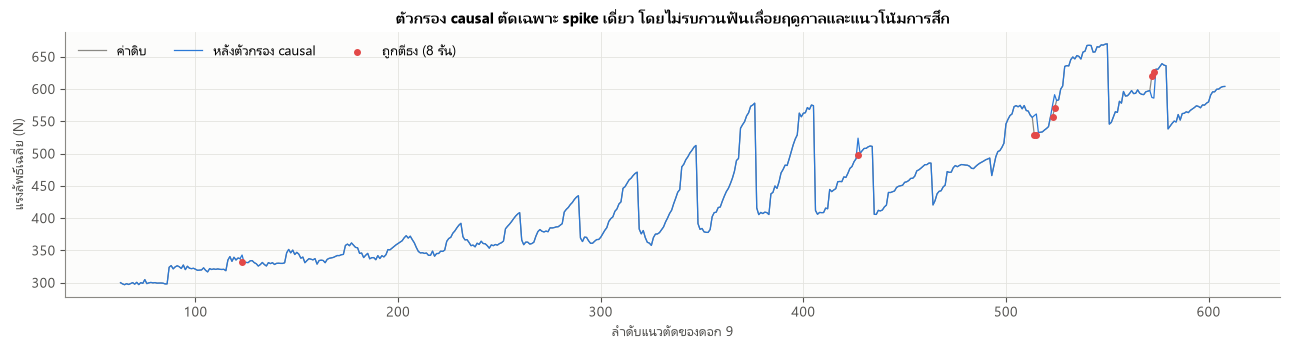

In [11]:
runs_causal, cflags = X.causal_clean_runs(runs_raw.drop(columns=["layer", "pos_in_layer"]))
cf = cflags.groupby(runs_raw.tool).sum().T
cf.columns = [f"T{c}" for c in cf.columns]
cf["รวม"] = cf.sum(axis=1); cf["%"] = (cf["รวม"] / len(runs_raw) * 100).round(2)
display(cf)
any_flag = cflags.any(axis=1)
print(f"รันที่ถูกตีธงอย่างน้อย 1 ตัวแปร: {any_flag.sum()} จาก {len(runs_raw)} ({any_flag.mean():.2%})")
sens = pd.DataFrame(json.loads((RES / "outlier_sensitivity.json").read_text(encoding="utf-8"))).T
sens.columns = ["MAE ทั้งอายุ (นาที)", "MAE 20% ท้าย (นาที)", "% พยากรณ์เกินจริง > 1 ชั้น"]
print("ความไวของแบบจำลอง RUL (GRU, leave-one-tool-out) ต่อวิธีจัดการ outlier"); display(sens)

t, col = 9, "fres_mean"
idx = runs_raw[runs_raw.tool == t].sort_values("run").index
x = runs_raw.loc[idx, col].values; xc = runs_causal.loc[idx, col].values; b = cflags.loc[idx, col].values
k = np.where(b)[0]; lo_, hi_ = max(k.min() - 60, 0), min(k.max() + 60, len(x))
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(np.arange(lo_, hi_), x[lo_:hi_], color=C["muted"], lw=0.9, label="ค่าดิบ")
ax.plot(np.arange(lo_, hi_), xc[lo_:hi_], color=C["blue"], lw=0.9, label="หลังตัวกรอง causal")
ax.scatter(k, x[k], color=C["red"], s=16, zorder=3, label=f"ถูกตีธง ({b.sum()} รัน)")
ax.set(xlabel="ลำดับแนวตัดของดอก 9", ylabel="แรงลัพธ์เฉลี่ย (N)", title="ตัวกรอง causal ตัดเฉพาะ spike เดี่ยว โดยไม่รบกวนฟันเลื่อยฤดูกาลและแนวโน้มการสึก")
ax.legend(ncol=3, loc="upper left"); fig.tight_layout(); savefig(fig, "r00_causal_filter"); plt.show()

**อ่านผล (ค):** ตัวกรอง causal ตีธงเพียง ~0.5% ของรัน (spike เดี่ยว) น้อยกว่า STL (~1–3%) เพราะ **outlier แบบกลุ่มทั้งชั้น** (เช่นดอก 1 ชั้น 16) ยืนยันไม่ได้ในเวลาจริง — ต้องรอให้ชั้นถัดไปกลับลงมาก่อนจึงรู้ว่าไม่ใช่การสึก ระบบจึงรับมือด้วย 3 ชั้น: (1) ฝึก GRU ด้วยสัญญาณรบกวนเสริมบนอินพุตเซนเซอร์ (2) ข้อจำกัดฟิสิกส์ที่รวมค่าประมาณอายุทั้งหมดด้วยมัธยฐาน ทำให้ชั้นผิดปกติ 1 ชั้นขยับผลได้น้อย (3) ตัววัด drift ของอินพุตบน dashboard ผลทดลองยืนยันว่า **ตัวกรอง causal ที่ใช้งานจริงให้ผลดีที่สุด** (ดีกว่าการทำความสะอาดด้วย STL ที่มองเห็นอนาคต) และการไม่ทำความสะอาดเลยแย่ที่สุด

---
# 3. การเตรียมข้อมูล (Data Preprocessing)

## 3.0 เลือกหน่วยเวลาของอนุกรม: "ชั้นงาน" ไม่ใช่ "แนวตัด"
ถ้า VB รายแนวเป็นค่าประมาณเชิงเส้นระหว่างจุดวัดจริง ค่า VB ภายในแต่ละช่วงวัดจะเรียงบนเส้นตรงเทียบกับเวลาตัดสะสมพอดี (คลาดเคลื่อนเพียงการปัดเป็นจำนวนเต็ม ±0.5 µm)

เส้นตรงต่อชั้น: |residual| สูงสุดมัธยฐาน = 0.51 µm, ชั้นที่ |residual| ≤ 1 µm = 100% จาก 221 ชั้น
ΔVB รายแนว (ค่าที่พบ: สัดส่วน): {0.0: 0.817, 1.0: 0.173, 2.0: 0.006, 3.0: 0.002, 5.0: 0.002}


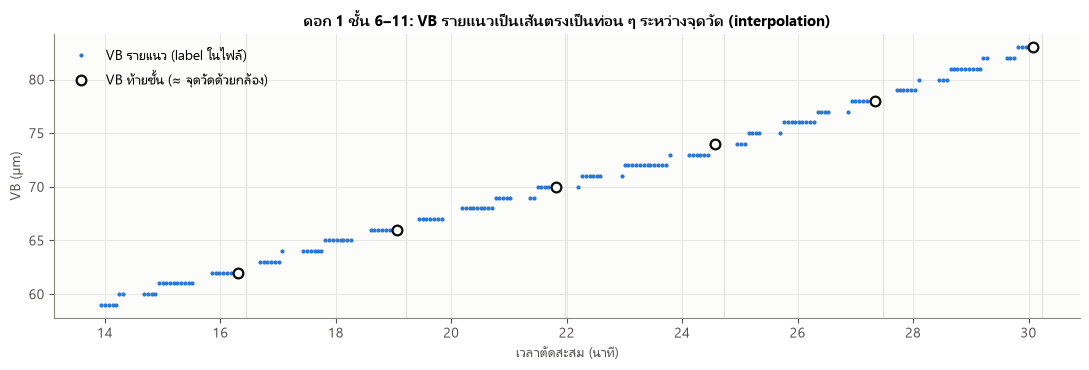

In [12]:
res = []
for (t, l), g in runs_raw.groupby(["tool", "layer"]):
    if len(g) < 10: continue
    c, v = g.contact.values, g.wear.values
    r = v - np.polyval(np.polyfit(c, v, 1), c)
    res.append(dict(tool=t, layer=l, max_abs_resid=np.abs(r).max()))
res = pd.DataFrame(res)
print(f"เส้นตรงต่อชั้น: |residual| สูงสุดมัธยฐาน = {res.max_abs_resid.median():.2f} µm, "
      f"ชั้นที่ |residual| ≤ 1 µm = {(res.max_abs_resid <= 1).mean():.0%} จาก {len(res)} ชั้น")
print("ΔVB รายแนว (ค่าที่พบ: สัดส่วน):", runs_raw.sort_values(["tool", "run"]).groupby("tool").wear.diff().value_counts(normalize=True).round(3).head(5).to_dict())
fig, ax = plt.subplots(figsize=(11, 3.8))
g = runs_raw[(runs_raw.tool == 1) & runs_raw.layer.between(6, 11)]
ax.plot(g.contact_min, g.wear, ".", color=C["blue"], ms=4, label="VB รายแนว (label ในไฟล์)")
Lg = g.groupby("layer").agg(c=("contact_min", "last"), v=("wear", "last"))
ax.plot(Lg.c, Lg.v, "o", color=C["ink"], ms=7, mfc="white", mew=1.6, label="VB ท้ายชั้น (≈ จุดวัดด้วยกล้อง)")
for c_ in Lg.c: ax.axvline(c_ + 0.15, color=C["grid"], lw=1)
ax.set(xlabel="เวลาตัดสะสม (นาที)", ylabel="VB (µm)", title="ดอก 1 ชั้น 6–11: VB รายแนวเป็นเส้นตรงเป็นท่อน ๆ ระหว่างจุดวัด (interpolation)")
ax.legend(); fig.tight_layout(); savefig(fig, "05_vb_interpolation"); plt.show()

ยืนยันว่า VB รายแนว **ไม่ใช่ค่าที่วัดได้จริง** แต่เป็นเส้นตรงระหว่างจุดวัด ผลที่ตามมาถ้าใช้รายแนวเป็นอนุกรมเวลา:
1. ค่า ΔVB รายแนวเป็น 0 เกือบทั้งหมด (สลับ 1 จากการปัดเศษ) — โครงสร้างสหสัมพันธ์ (ACF) เป็นของเทียมจากการประมาณค่า ไม่ใช่ของกระบวนการ
2. **ข้อมูลรั่วจากอนาคต:** ค่า VB ระหว่างจุดวัดถูกคำนวณจากจุดวัด *ถัดไป* ถ้าพยากรณ์จากกลางชั้นจะ "รู้" ทิศทางของจุดวัดถัดไปอยู่แล้ว

**จึงสร้างอนุกรมที่ความถี่ของการวัดจริง: 1 จุดต่อชั้นงาน** (VB ท้ายชั้น, เวลาตัดต่อชั้นเท่ากันทุกชั้น ≈ 164 s ≈ 2.7 นาที) และรวมฟีเจอร์เซนเซอร์ของ 29 แนวในชั้นด้วย **มัธยฐาน** ซึ่งตัดชั้นแรก (break-in) ออก เพราะเป็นอีกระบอบหนึ่ง (VB กระโดด 0 → ~40 µm ใน 1 ชั้น) ที่ไม่เกี่ยวกับการพยากรณ์ช่วงปลายอายุ

In [13]:
L = W.layer_table(runs_clean)
S = W.build_series(L)
L[["tool", "machine", "layer", "VB", "C_end", "cmin", "n_runs"] + W.RAW_LAYER_COLS + W.HI_COLS].to_csv(RES / "layer_series.csv", index=False)
print({t: f"{len(s)} ชั้น (ชั้น {s.layer[0]}–{s.layer[-1]})" for t, s in S.items()})
display(L[L.layer >= W.FIRST_LAYER][["VB", "cmin"] + W.HI_COLS].describe().T.round(3))

{1: '20 ชั้น (ชั้น 2–21)', 2: '20 ชั้น (ชั้น 2–21)', 3: '21 ชั้น (ชั้น 2–22)', 4: '31 ชั้น (ชั้น 2–32)', 5: '31 ชั้น (ชั้น 2–32)', 6: '31 ชั้น (ชั้น 2–32)', 7: '20 ชั้น (ชั้น 2–21)', 8: '19 ชั้น (ชั้น 3–21)', 9: '20 ชั้น (ชั้น 2–21)'}


,count,mean,std,min,25%,50%,75%,max
VB,213.0,85.737,28.986,42.000,61.000,81.000,102.000,160.000
cmin,213.0,37.897,21.118,5.183,21.300,35.800,52.350,86.350
sp_rel,213.0,0.140,0.096,-0.021,0.057,0.132,0.217,0.364
ay_rel,213.0,0.371,0.368,0.000,0.095,0.259,0.528,1.701
ax_rel,213.0,0.414,0.307,0.000,0.154,0.378,0.620,1.265
fx_rel,213.0,0.616,0.444,-0.000,0.200,0.570,0.991,1.785
fres_rel,213.0,0.539,0.465,-0.150,0.170,0.404,0.887,1.773
fy_d,213.0,0.304,0.254,0.000,0.083,0.257,0.479,1.040
fz_d,213.0,-0.114,0.093,-0.374,-0.172,-0.089,-0.034,0.000


## 3.1 แนวโน้ม (Trend)
ใช้ 2 วิธี: **Mann-Kendall** (Kendall's τ ระหว่างค่ากับเวลา; τ ใกล้ 1 = เพิ่มขึ้นทางเดียว) บนอนุกรมรายชั้น และ **ความแรงของ trend จาก STL** บนอนุกรมรายแนว $F_T = \max(0, 1 - \mathrm{Var}(R)/\mathrm{Var}(T+R))$

In [14]:
rows = []
for t, s in S.items():
    r = dict(tool=t, machine=s.machine)
    for name, x in [("VB", s.vb), ("sp_rel", s.X[:, 0]), ("ay_rel", s.X[:, 1]), ("fx_rel", s.X[:, 3])]:
        tau_, p_ = stats.kendalltau(np.arange(len(x)), x); r[f"τ {name}"] = tau_; r[f"p {name}"] = p_
    for col in ["sp_rms", "fx_mean"]:
        x = np.log(runs_clean[runs_clean.tool == t].sort_values("run")[col].values)
        st = STL(x, period=29, robust=True).fit()
        r[f"F_T {col}"] = max(0, 1 - np.var(st.resid) / np.var(st.trend + st.resid))
        r[f"F_S {col}"] = max(0, 1 - np.var(st.resid) / np.var(st.seasonal + st.resid))
    rows.append(r)
trend_tab = pd.DataFrame(rows).set_index("tool")
display(trend_tab.round(3))

,machine,τ VB,p VB,τ sp_rel,p sp_rel,τ ay_rel,p ay_rel,τ fx_rel,p fx_rel,F_T sp_rms,F_S sp_rms,F_T fx_mean,F_S fx_mean
tool,,,,,,,,,,,,,
1,1,1.000,0.0,1.000,0.0,1.000,0.0,0.937,0.0,0.998,0.893,0.994,0.638
2,1,1.000,0.0,1.000,0.0,1.000,0.0,1.000,0.0,0.999,0.950,1.000,0.976
3,1,1.000,0.0,0.952,0.0,1.000,0.0,1.000,0.0,0.993,0.831,1.000,0.989
4,2,0.999,0.0,1.000,0.0,0.996,0.0,1.000,0.0,0.998,0.667,1.000,0.964
5,2,1.000,0.0,0.983,0.0,0.978,0.0,0.970,0.0,0.996,0.591,0.999,0.853
6,2,0.992,0.0,1.000,0.0,0.991,0.0,1.000,0.0,0.998,0.506,1.000,0.974
7,3,1.000,0.0,1.000,0.0,0.979,0.0,1.000,0.0,0.994,0.745,1.000,0.965
8,3,1.000,0.0,1.000,0.0,0.930,0.0,1.000,0.0,0.997,0.953,1.000,0.994
9,3,1.000,0.0,1.000,0.0,0.989,0.0,0.989,0.0,0.997,0.925,0.999,0.968


**ผล:** VB มี Kendall τ = 1.00 ทุกดอก (เพิ่มขึ้นทางเดียวสมบูรณ์ — ตรงกับฟิสิกส์ที่รอยสึกไม่ลดลง) health indicator ก็มี τ สูง และ $F_T$ ใกล้ 1 → **มี trend ชัดเจนมาก** ซึ่งเป็นสาระหลักของการพยากรณ์

## 3.2 ฤดูกาล (Seasonality)
ตัด trend ด้วย rolling median 59 แนว แล้วหาคาบเด่นด้วย periodogram

tool,1,2,3,4,5,6,7,8,9
คาบเด่น sp_rms (แนว),29.0,29.0,29.0,29.0,29.0,29.0,29.0,29.5,29.0
คาบเด่น fx_mean (แนว),29.0,29.0,29.0,29.0,29.0,29.0,29.0,29.5,29.0


ความชันของรูปแบบฤดูกาลเทียบ x (% ต่อ 100 mm): {1: np.float64(6.3), 2: np.float64(6.5), 3: np.float64(8.6), 4: np.float64(3.3), 5: np.float64(3.4), 6: np.float64(3.5), 7: np.float64(4.8), 8: np.float64(-8.8), 9: np.float64(7.6)}


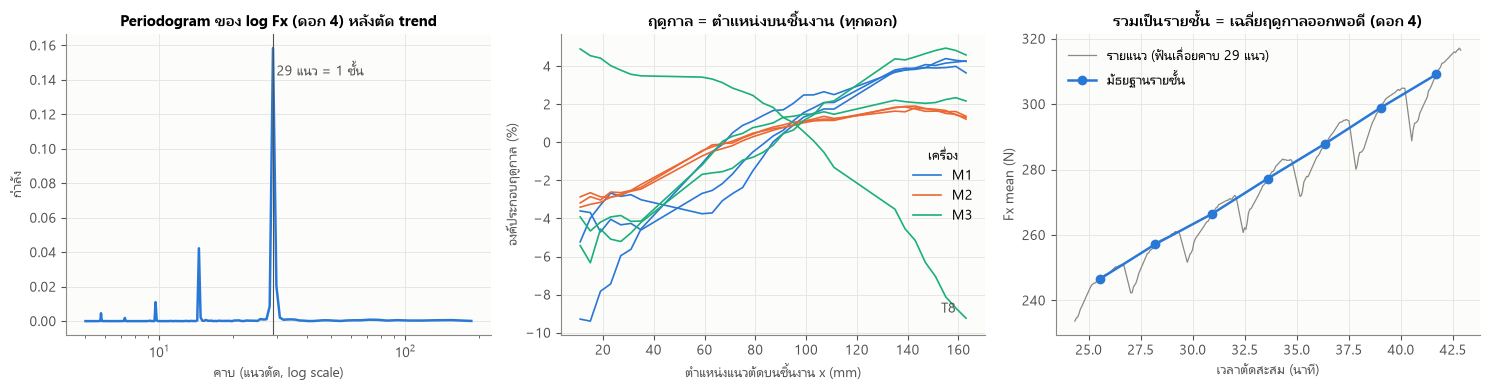

In [15]:
from scipy.signal import periodogram
per_rows = []
for t, g in runs_clean.groupby("tool"):
    g = g.sort_values("run"); r = dict(tool=t)
    for col in ["sp_rms", "fx_mean"]:
        x = np.log(g[col].values); d = x - pd.Series(x).rolling(59, center=True, min_periods=1).median().values
        fr, P = periodogram(d); m = fr > 0.005
        r[f"คาบเด่น {col} (แนว)"] = round(1 / fr[m][np.argmax(P[m])], 1)
    per_rows.append(r)
display(pd.DataFrame(per_rows).set_index("tool").T)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
g = runs_clean[runs_clean.tool == 4].sort_values("run")
x = np.log(g.fx_mean.values); d = x - pd.Series(x).rolling(59, center=True, min_periods=1).median().values
fr, P = periodogram(d); m = (fr > 0.005) & (fr < 0.2)
ax[0].plot(1 / fr[m], P[m], color=C["blue"]); ax[0].set_xscale("log")
ax[0].axvline(29, color=C["ink2"], lw=0.8); ax[0].text(30, P[m].max() * 0.9, "29 แนว = 1 ชั้น", color=C["ink2"])
ax[0].set(xlabel="คาบ (แนวตัด, log scale)", ylabel="กำลัง", title="Periodogram ของ log Fx (ดอก 4) หลังตัด trend")
prof_slope = {}
for t, gg in runs_clean.groupby("tool"):
    gg = gg.sort_values("run"); xx = np.log(gg.fx_mean.values); st = STL(xx, period=29, robust=True).fit()
    prof = pd.DataFrame({"x": np.round(gg.x_pos.values), "s": st.seasonal * 100}).groupby("x").s.median()
    prof_slope[t] = np.polyfit(prof.index, prof.values, 1)[0] * 100
    ax[1].plot(prof.index, prof.values, color=MACHINE_COLOR[int(gg.machine.iloc[0])], lw=1.2,
               label=f"M{int(gg.machine.iloc[0])}" if t in (1, 4, 7) else None)
    if prof_slope[t] < 0:
        ax[1].annotate(f"T{t}", (prof.index[-1], prof.values[-1]), xytext=(-18, 4), textcoords="offset points", color=C["ink2"])
ax[1].set(xlabel="ตำแหน่งแนวตัดบนชิ้นงาน x (mm)", ylabel="องค์ประกอบฤดูกาล (%)", title="ฤดูกาล = ตำแหน่งบนชิ้นงาน (ทุกดอก)")
ax[1].legend(title="เครื่อง")
print("ความชันของรูปแบบฤดูกาลเทียบ x (% ต่อ 100 mm):", {t: round(v, 1) for t, v in prof_slope.items()})
g4 = runs_clean[(runs_clean.tool == 4) & runs_clean.layer.between(10, 16)].sort_values("run")
ax[2].plot(g4.contact_min, g4.fx_mean, color=C["muted"], lw=0.9, label="รายแนว (ฟันเลื่อยคาบ 29 แนว)")
lm_ = g4.groupby("layer").agg(c=("contact_min", "median"), f=("fx_mean", "median"))
ax[2].plot(lm_.c, lm_.f, color=C["blue"], marker="o", label="มัธยฐานรายชั้น")
ax[2].set(xlabel="เวลาตัดสะสม (นาที)", ylabel="Fx mean (N)", title="รวมเป็นรายชั้น = เฉลี่ยฤดูกาลออกพอดี (ดอก 4)")
ax[2].legend(loc="upper left")
fig.tight_layout(); savefig(fig, "06_seasonality"); plt.show()

**ผล:** health indicator รายแนวมี **ฤดูกาลคาบ 29 แนว ในทุกดอกทุกเครื่อง** ($F_S$ ของ Fx 0.4–0.9) รูปแบบเป็นฟันเลื่อย: แรงค่อย ๆ เพิ่มเมื่อดอกกัดเลื่อนจาก x = 11 ไป 163 mm แล้วรีเซ็ตเมื่อขึ้นชั้นใหม่ 29 แนว = จำนวนแนวที่บันทึกต่อชั้นพอดี จึงเป็น **"ฤดูกาลเชิงตำแหน่ง" (ตำแหน่งบนชิ้นงาน/ระยะจากจุดจับยึดและ dynamometer) ไม่ใช่การสึก**

ดอก 8 มีรูปแบบ *กลับทิศ* (ความชันเทียบ x = −8.8% ต่อ 100 mm ขณะที่ดอกอื่น +3.3 ถึง +8.6%) เอกสารต้นทางระบุว่าการทดลองของ T7 และ T8 ระบบพิกัดชิ้นงานเอียงจากแกนเครื่อง 1–2° (ความกว้างตัดจึงเปลี่ยนตามตำแหน่ง) ซึ่งเป็นคำอธิบายที่เป็นไปได้สำหรับดอก 8 (ดอก 7 ไม่แสดงความต่างชัด) — ทั้งหมดชี้ว่าฤดูกาลนี้เป็น **ผลเชิงเรขาคณิต/ตำแหน่งของการตัด ไม่ใช่การสึก**

ผลต่อการสร้างแบบจำลอง: ถ้ารวมเป็นรายชั้น (1 ชั้น = 1 คาบเต็มพอดี) ฤดูกาลจะเฉลี่ยออกไปเอง (รูปขวา) แต่แบบจำลอง RUL ต้องอัปเดตทุกรัน จึงใช้ **หน้าต่างอินพุต 29 รันล่าสุด (= 1 คาบเต็ม)** และให้ **ตำแหน่ง x ของแนวตัด** เป็นอินพุต เพื่อให้แบบจำลองแยก "ฤดูกาลเชิงตำแหน่ง" ออกจากการสึกได้เอง (หัวข้อ 3.8) → ไม่ต้องตัดฤดูกาลด้วย SARIMA / Holt-Winters ส่วนตัว VB เองไม่มีฤดูกาลอยู่แล้ว (ACF ของ ΔVB ไม่มี spike เป็นคาบ ดูหัวข้อ 3.5)

## 3.3 วัฏจักร (Cyclic)
วัฏจักร = การขึ้นลงที่ *ไม่มีคาบตายตัว* ตรวจจากส่วนที่เหลือ (residual) หลังแยก trend และ seasonal ด้วย STL

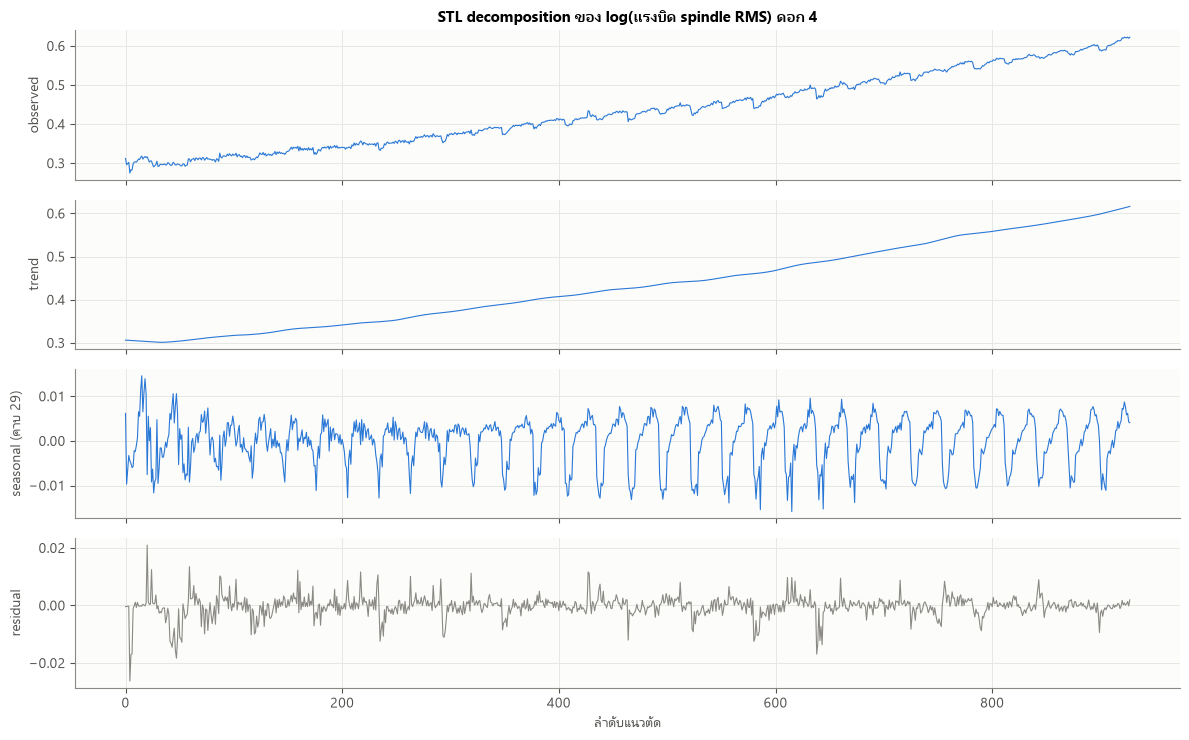

,ACF lag 1,ACF lag 5,ACF lag 29,ACF lag 58,ACF lag 116,lag_ที่ACFหมดนัยสําคัญ,ACF lag 1 ของ residual รายชั้น,แอมพลิจูด residual รายชั้น (%)
tool,,,,,,,,
1,0.88,0.47,-0.02,0.06,0.24,10,-0.23,0.07
2,0.74,0.32,0.00,0.41,0.13,9,0.04,0.06
3,0.90,0.70,-0.13,-0.06,0.24,18,-0.15,0.17
4,0.47,0.20,-0.12,0.15,0.10,11,-0.50,0.14
5,0.69,0.31,-0.10,0.09,0.09,11,-0.25,0.17
6,0.38,0.17,-0.14,0.34,0.29,10,-0.75,0.19
7,0.26,0.07,-0.02,-0.06,0.07,3,0.07,0.16
8,0.18,-0.05,-0.13,-0.05,-0.01,2,-0.50,0.06
9,0.22,0.00,-0.08,-0.02,-0.02,2,-0.31,0.09


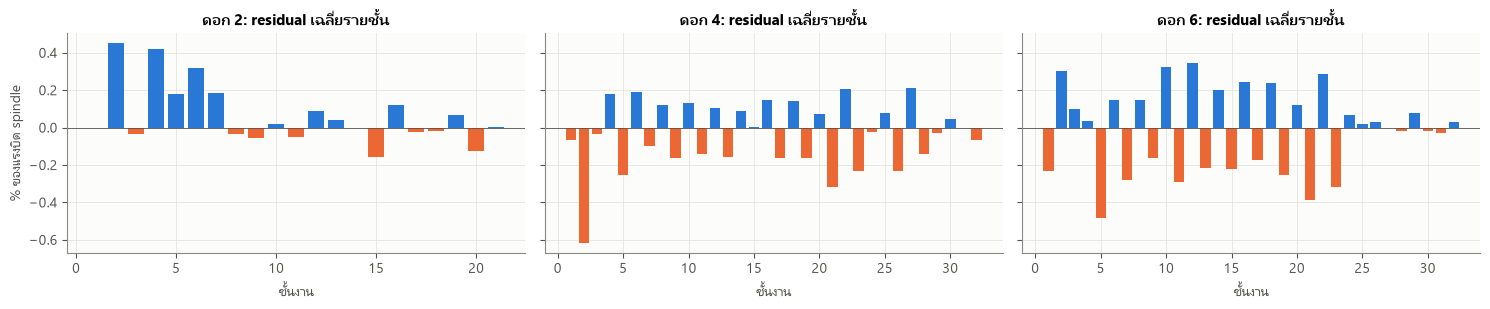

In [16]:
from statsmodels.tsa.stattools import acf as acf_fn
g = runs_clean[runs_clean.tool == 4].sort_values("run")
st = STL(np.log(g.sp_rms.values), period=29, robust=True).fit()
fig, ax = plt.subplots(4, 1, figsize=(12, 7.5), sharex=True)
for a_, comp, lab in zip(ax, [st.observed, st.trend, st.seasonal, st.resid], ["observed", "trend", "seasonal (คาบ 29)", "residual"]):
    a_.plot(comp, color=C["blue"] if lab != "residual" else C["muted"], lw=0.8); a_.set_ylabel(lab)
ax[0].set_title("STL decomposition ของ log(แรงบิด spindle RMS) ดอก 4"); ax[-1].set_xlabel("ลำดับแนวตัด")
fig.tight_layout(); savefig(fig, "07_stl"); plt.show()
cyc, lay_res = [], {}
for t, gg in runs_clean.groupby("tool"):
    gg = gg.sort_values("run")
    st_ = STL(np.log(gg.sp_rms.values), period=29, robust=True).fit()
    a = acf_fn(st_.resid, nlags=120)
    first_insig = int(np.argmax(np.abs(a[1:]) < 1.96 / np.sqrt(len(st_.resid)))) + 1
    lm = pd.Series(st_.resid * 100).groupby(gg.layer.values).mean()        # residual เฉลี่ยรายชั้น (%)
    lay_res[t] = lm
    cyc.append(dict(tool=t, **{f"ACF lag {k}": a[k] for k in (1, 5, 29, 58, 116)}, lag_ที่ACFหมดนัยสำคัญ=first_insig,
                    **{"ACF lag 1 ของ residual รายชั้น": lm.autocorr(1), "แอมพลิจูด residual รายชั้น (%)": lm.abs().median()}))
display(pd.DataFrame(cyc).set_index("tool").round(2))
fig, ax = plt.subplots(1, 3, figsize=(15, 3.2), sharey=True)
for a_, t in zip(ax, [2, 4, 6]):
    lm = lay_res[t]
    a_.bar(lm.index, lm.values, color=[C["blue"] if v >= 0 else C["orange"] for v in lm.values], width=0.8)
    a_.set(title=f"ดอก {t}: residual เฉลี่ยรายชั้น", xlabel="ชั้นงาน"); a_.axhline(0, color=C["ink2"], lw=0.6)
ax[0].set_ylabel("% ของแรงบิด spindle")
fig.tight_layout(); savefig(fig, "07b_cyclic"); plt.show()

**ผล:**
- ACF ของ residual สูงเฉพาะ lag สั้น (ความจำระยะสั้นไม่กี่แนว) แล้วหมดนัยสำคัญภายใน 2–18 แนว ที่ lag 29 ไม่มีค่ายอด (ฤดูกาลถูกแยกออกหมดแล้ว)
- แต่ **ดอก 2, 4, 6 มี ACF ที่ lag 58 (= 2 ชั้น) เด่น 0.15–0.41** และ residual เฉลี่ยรายชั้นของเครื่อง M2 **สลับขึ้น–ลงทีละชั้น** (ACF lag 1 รายชั้นติดลบ) เฉพาะช่วงกลางอายุ → เป็น **องค์ประกอบวัฏจักร** (คาบไม่คงที่ตลอดอายุ จึงไม่ใช่ฤดูกาล) ที่สอดคล้องกับจังหวะการถอดดอกไปวัด VB *ทุก 2 ชั้นช่วงกลางอายุ* ตามเอกสารต้นทาง (สมมติฐาน: การจับยึดใหม่เปลี่ยน runout เล็กน้อย)
- ขนาดเพียง ~0.06–0.19% ของแรงบิด (มัธยฐานของ |residual รายชั้น|) ขณะที่การสึกทำให้แรงบิดเปลี่ยน ~1.5% ต่อชั้น → **เล็กมากจนไม่กระทบการพยากรณ์** จึงถือเป็นสัญญาณรบกวน ไม่สร้างองค์ประกอบวัฏจักรในแบบจำลอง
- การเปลี่ยน *ระยะ* ของการสึก (break-in → steady → accelerated) เกิดเพียงครั้งเดียวต่ออายุดอก จึงไม่ใช่วัฏจักร แต่เป็น **การเปลี่ยนระบอบ (regime change)** — แบบจำลองในหัวข้อ 4 จึงต้องรองรับการเปลี่ยนระบอบ (SETAR / เส้นทางการสึกที่มีระบอบอยู่ในตัว)

## 3.4 ความนิ่งของข้อมูล — Augmented Dickey-Fuller (ADF) Test
- $H_0$: อนุกรมมี unit root (ไม่นิ่ง) · ระดับนัยสำคัญ 0.05 · จำนวน lag สูงสุด $\lfloor (n-1)^{1/3} \rfloor$ (เหมาะกับอนุกรมสั้น) เลือกด้วย AIC
- ทดสอบบน **ส่วนฝึก (80% แรก) ของแต่ละดอก** เพื่อไม่ให้ข้อมูลทดสอบมีผลต่อการเลือก d
- เสริมด้วย **KPSS** ($H_0$: นิ่ง) เพราะ ADF มีกำลังทดสอบต่ำกับอนุกรมสั้น (16–25 จุด)

In [17]:
from statsmodels.tsa.stattools import kpss
def kpss_p(y):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return kpss(y, regression="c", nlags="auto")[1]
rows = []
for t, s in S.items():
    y = s.vb[:s.n_train]
    rows.append({"tool": t, "n": len(y),
                 "ADF p (VB)": W.adf_pvalue(y), "ADF p (ΔVB)": W.adf_pvalue(np.diff(y)), "ADF p (Δ²VB)": W.adf_pvalue(np.diff(y, 2)),
                 "KPSS p (VB)": kpss_p(y), "KPSS p (ΔVB)": kpss_p(np.diff(y)), "d ที่เลือก (ADF)": W.choose_d(y)})
adf_tab = pd.DataFrame(rows).set_index("tool")
display(adf_tab.round(4))
print("สรุป: ระดับเดิมไม่นิ่ง", (adf_tab["ADF p (VB)"] >= 0.05).sum(), "/ 9 ดอก | ΔVB นิ่ง", (adf_tab["ADF p (ΔVB)"] < 0.05).sum(),
      "/ 9 | Δ²VB นิ่ง", (adf_tab["ADF p (Δ²VB)"] < 0.05).sum(), "/ 9")
# health indicator รายแนว (อนุกรมยาว) เพื่อเปรียบเทียบ
rows = []
for t, g in runs_clean.groupby("tool"):
    x = np.log(g.sort_values("run").sp_rms.values)
    from statsmodels.tsa.stattools import adfuller
    rows.append(dict(tool=t, **{"ADF p log sp_rms (level)": adfuller(x, autolag="AIC")[1], "ADF p (Δ)": adfuller(np.diff(x), autolag="AIC")[1]}))
display(pd.DataFrame(rows).set_index("tool").T.round(4))

,n,ADF p (VB),ADF p (ΔVB),ADF p (Δ²VB),KPSS p (VB),KPSS p (ΔVB),d ที่เลือก (ADF)
tool,,,,,,,
1,16,1.0000,0.5488,0.0000,0.0187,0.0436,2
2,16,0.9913,0.3401,0.0005,0.0182,0.1000,2
3,17,1.0000,0.1733,0.0395,0.0158,0.0816,2
4,25,0.9915,0.2894,0.0000,0.0106,0.1000,2
5,25,0.8713,0.0001,0.0000,0.0100,0.1000,1
6,25,0.9971,0.0916,0.0021,0.0108,0.1000,2
7,16,0.9982,0.6571,0.0000,0.0200,0.0802,2
8,15,1.0000,0.4368,0.0003,0.0224,0.0631,2
9,16,0.9986,0.9153,0.0000,0.0198,0.1000,2


สรุป: ระดับเดิมไม่นิ่ง 9 / 9 ดอก | ΔVB นิ่ง 1 / 9 | Δ²VB นิ่ง 9 / 9


tool,1,2,3,4,5,6,7,8,9
ADF p log sp_rms (level),0.6649,0.7966,0.5269,0.9988,0.984,0.9935,0.8374,0.3624,0.9051
ADF p (Δ),0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000


**อ่านผล ADF:**
- **VB ระดับเดิมไม่นิ่งทั้ง 9 ดอก** (ADF p = 0.87–1.00 และ KPSS ปฏิเสธความนิ่ง p ≤ 0.02 ทุกดอก — สองการทดสอบสอดคล้องกัน)
- **ΔVB (อัตราสึกต่อชั้น): ADF ปฏิเสธ unit root เพียง 1/9 ดอก** (ดอก 5) แต่ KPSS ส่วนใหญ่ก็ปฏิเสธความนิ่งไม่ได้ → ผลกำกวม เป็นอาการของอนุกรมสั้น (15–25 จุด) ที่การทดสอบมีกำลังต่ำ *และ* อัตราสึกที่เปลี่ยนระดับ (ช้าลงหลัง break-in และเร็วขึ้นช่วงท้าย)
- **Δ²VB นิ่งทั้ง 9 ดอก** → ถ้าใช้ ARIMA กับ VB ต้อง d = 2 (= ต่อเส้นความชันล่าสุดออกไปตรง ๆ ไม่รู้จักการเปลี่ยนระบอบสึกเร่ง) — เหตุผลหนึ่งที่ไม่ใช้ ARIMA รายดอก
- ความหมายเชิงฟิสิกส์: VB ไม่นิ่งเพราะเป็นการสะสมความเสียหายที่ย้อนกลับไม่ได้ ส่วน ΔVB **ไม่ได้นิ่งรอบค่าคงที่เดียว แต่ระดับของมันเปลี่ยนตามสภาพการสึก** — ARIMA จัดการด้วยการ differencing ซ้ำ (ซึ่งทำให้ต่อเส้นความชันล่าสุดออกไป) ขณะที่แบบจำลอง state-space ในหัวข้อ 4 ใช้เส้นทางการสึกที่มีการเปลี่ยนระบอบอยู่ในตัว (และใช้ SETAR เป็น prior ทางฟิสิกส์)

## 3.5 ACF / PACF ของอนุกรมหลัง differencing

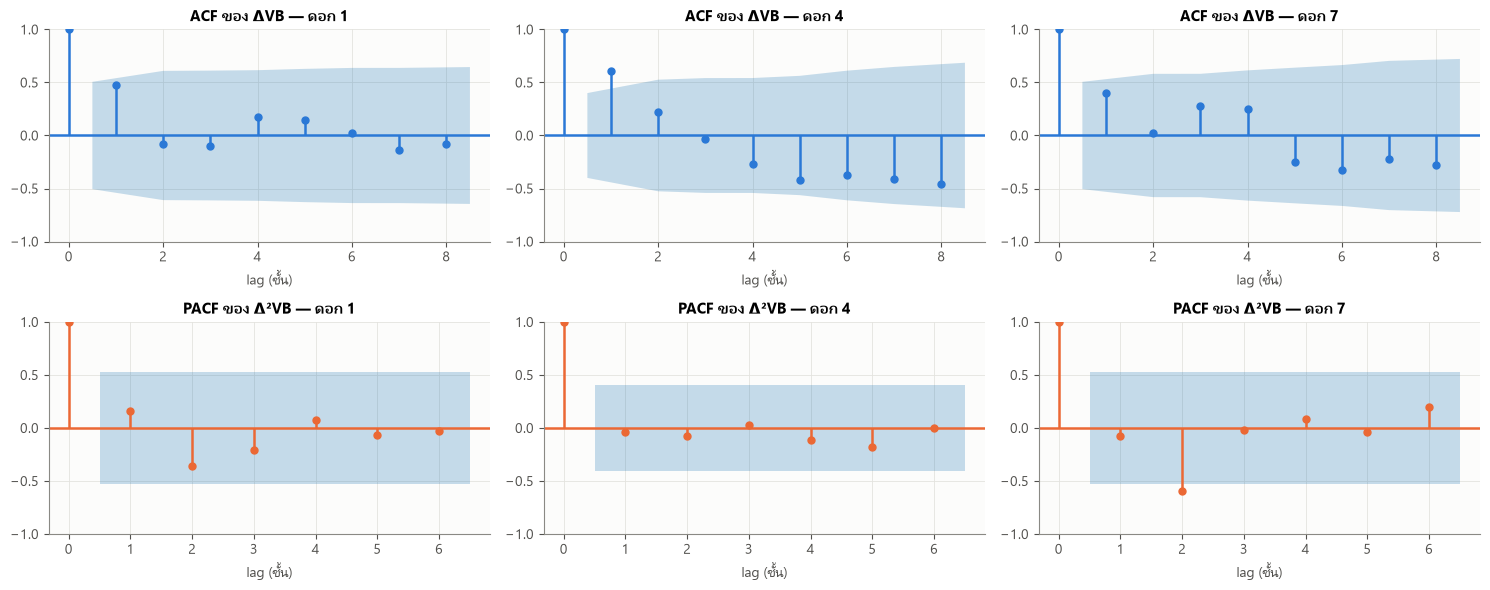

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
for j, t in enumerate([1, 4, 7]):
    y = S[t].vb[:S[t].n_train]
    plot_acf(np.diff(y), ax=ax[0, j], lags=8, color=C["blue"], vlines_kwargs={"colors": C["blue"]}, title=f"ACF ของ ΔVB — ดอก {t}")
    plot_pacf(np.diff(y, 2), ax=ax[1, j], lags=6, method="ywm", color=C["orange"], vlines_kwargs={"colors": C["orange"]}, title=f"PACF ของ Δ²VB — ดอก {t}")
    for a_ in ax[:, j]: a_.set_xlabel("lag (ชั้น)")
fig.tight_layout(); savefig(fig, "08_acf_pacf"); plt.show()

ACF ของ ΔVB ลดลงช้า ๆ (ไม่ตัดฉับ) = ยังมี trend ในอัตราสึก ส่วน Δ²VB มีสหสัมพันธ์ติดลบที่ lag 1 บางดอก ซึ่งส่วนหนึ่งมาจาก *การวัดทุก 2 ชั้นช่วงกลางอายุ* (ค่าชั้นที่ไม่ได้วัดเป็นค่ากึ่งกลาง ทำให้ ΔVB มาเป็นคู่) ไม่พบ spike ที่ lag ใดเป็นคาบ → ยืนยันว่าไม่มีฤดูกาลใน VB โครงสร้าง AR/MA รายดอกจึงไม่ชัดและอนุกรมรายชั้นสั้นมาก (15–31 จุด) — สนับสนุนการใช้แบบจำลองที่เรียนพลวัตร่วมจากหลายดอก

## 3.6 การวิเคราะห์เชิงฟิสิกส์: อัตราการสึกขึ้นกับ "สภาพการสึกปัจจุบัน"
ทฤษฎีการสึกของเครื่องมือตัด: เมื่อรอยสึกด้านข้างกว้างขึ้น พื้นที่เสียดสีระหว่างผิวหลบกับชิ้นงานเพิ่ม → อุณหภูมิที่คมตัดสูงขึ้น → กลไกการสึกที่ไวต่ออุณหภูมิ (diffusion/oxidation) เร่งตัว จึงเกิด *ช่วงสึกเร่ง* หลังรอยสึกเกินค่าวิกฤต ถ้าเป็นจริง ΔVB ควรขึ้นกับระดับ VB ก่อนหน้า

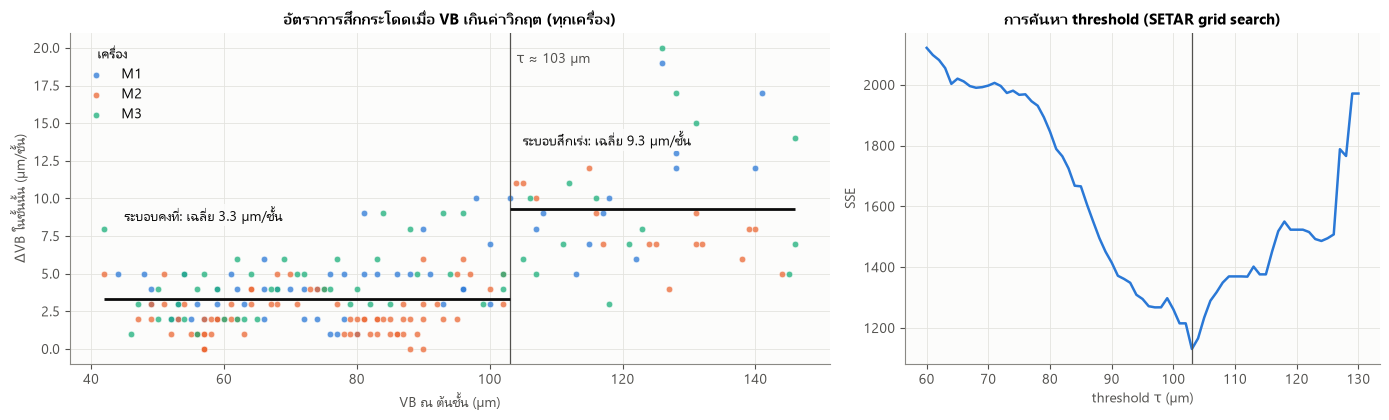

regime,accelerated,steady,machine,ratio
tool,,,,
1,10.20,4.14,1,2.46
2,12.33,3.75,1,3.29
3,9.80,3.93,1,2.49
4,7.50,2.29,2,3.27
5,8.20,2.60,2,3.15
6,8.40,2.16,2,3.89
7,11.75,4.00,3,2.94
8,7.50,4.33,3,1.73
9,10.60,4.64,3,2.28


In [19]:
pairs = pd.concat([pd.DataFrame({"tool": t, "machine": s.machine, "VB_prev": s.vb[:-1], "dVB": np.diff(s.vb)}) for t, s in S.items()])
tar_all = W.PhysicsTAR("step").fit([s.vb for s in S.values()])
fig, ax = plt.subplots(1, 2, figsize=(14, 4.3), gridspec_kw={"width_ratios": [1.6, 1]})
for m, g in pairs.groupby("machine"):
    ax[0].scatter(g.VB_prev, g.dVB, s=22, color=MACHINE_COLOR[m], alpha=0.75, edgecolor="white", lw=0.5, label=f"M{m}")
ax[0].axvline(tar_all.tau, color=C["ink2"], lw=0.9)
ax[0].text(tar_all.tau + 1, pairs.dVB.max() * 0.95, f"τ ≈ {tar_all.tau:.0f} µm", color=C["ink2"])
lo, hi = pairs[pairs.VB_prev < tar_all.tau].dVB.mean(), pairs[pairs.VB_prev >= tar_all.tau].dVB.mean()
ax[0].hlines([lo, hi], [pairs.VB_prev.min(), tar_all.tau], [tar_all.tau, pairs.VB_prev.max()], color=C["ink"], lw=2)
bb = dict(facecolor=C["surface"], edgecolor="none", alpha=0.85, pad=1.5)
ax[0].text(45, lo + 5.2, f"ระบอบคงที่: เฉลี่ย {lo:.1f} µm/ชั้น", color=C["ink"], bbox=bb); ax[0].text(tar_all.tau + 2, hi + 4.2, f"ระบอบสึกเร่ง: เฉลี่ย {hi:.1f} µm/ชั้น", color=C["ink"], bbox=bb)
ax[0].set(xlabel="VB ณ ต้นชั้น (µm)", ylabel="ΔVB ในชั้นนั้น (µm/ชั้น)", title="อัตราการสึกกระโดดเมื่อ VB เกินค่าวิกฤต (ทุกเครื่อง)")
ax[0].legend(title="เครื่อง")
prof = np.array(tar_all.profile)
ax[1].plot(prof[:, 0], prof[:, 1], color=C["blue"]); ax[1].axvline(tar_all.tau, color=C["ink2"], lw=0.9)
ax[1].set(xlabel="threshold τ (µm)", ylabel="SSE", title="การค้นหา threshold (SETAR grid search)")
fig.tight_layout(); savefig(fig, "09_wear_rate_physics"); plt.show()
rate_tab = pairs.assign(regime=np.where(pairs.VB_prev >= tar_all.tau, "accelerated", "steady")).pivot_table(index="tool", columns="regime", values="dVB", aggfunc="mean")
rate_tab["machine"] = [S[t].machine for t in rate_tab.index]; rate_tab["ratio"] = rate_tab.accelerated / rate_tab.steady
display(rate_tab.round(2))

**ผลสำคัญที่สุดของการวิเคราะห์ข้อมูล:**
1. อัตราสึก (ΔVB) **ขึ้นกับระดับ VB** ชัดเจน: ต่ำและค่อนข้างคงที่จนถึง ~100 µm แล้ว **กระโดดขึ้น** ในทุกดอกทุกเครื่อง (= ข้อมูลมี *regime 2 ระบอบ* ที่ถูกกำหนดด้วยระดับของอนุกรมเอง)
2. อัตราสึกช่วงคงที่ **ต่างกันตามดอก/เครื่อง** (M2 ≈ 2 µm/ชั้น, M1/M3 ≈ 3–4.5 µm/ชั้น) แต่ *ส่วนที่เพิ่มขึ้น* ในช่วงสึกเร่งใกล้เคียงกันทุกเครื่อง (+~6 µm/ชั้น) → ส่วนเร่งเป็น "ฟิสิกส์ร่วม" ที่เรียนจากดอกอื่นได้ ส่วนอัตราคงที่ต้องปรับตามดอกเอง
3. ช่วงทดสอบ (20% ท้าย) **อยู่ในช่วงสึกเร่งเกือบทั้งหมด** ขณะที่ส่วนฝึกของดอกเดียวกันแทบไม่มีระบอบนี้ → แบบจำลองที่แค่ต่อเส้นแนวโน้มจากอดีตของดอกนั้นจะพยากรณ์ต่ำเกินจริงอย่างเป็นระบบ

## 3.7 จาก VB สู่ label: RUL และสถานะตามเส้นโค้งการสึก
**ข้อสังเกตจาก 3.0:** VB รายแนวเป็นค่าประมาณเชิงเส้นระหว่างจุดวัด ถ้าใช้เป็นเป้าหมายรายรันจะรั่วข้อมูลอนาคต แต่ label ของงานนี้คือ **เวลาที่ VB ข้ามเกณฑ์** ซึ่งเป็นค่าคงที่ 1 ค่าต่อดอก ($T_{EOL}$, $T_{ACC}$) หาจากการ interpolate ระหว่างจุดวัดสองจุดที่คร่อมเกณฑ์ (ความคลาดไม่เกินระยะระหว่างจุดวัด) แล้วสร้าง label ทุกรันเป็น
$$\text{RUL}_t = \max(T_{EOL} - t,\ 0), \qquad \text{RUL}^{ACC}_t = \max(T_{ACC} - t,\ 0)$$
เมื่อ $t$ = เวลาตัดสะสม (นาที) สถานะ: **STEADY** (VB < 103 µm) → **ACCELERATED** (103 ≤ VB < 140) → **END_OF_LIFE** (VB ≥ 140)

,machine,T_acc,T_eol,accel_pct,first_pred_min,n_runs,n_windows
tool,,,,,,,
1,1,42.22,54.50,77.46,5.30,609,552
2,1,47.30,56.29,84.02,5.25,609,552
3,1,46.45,57.93,80.18,5.33,638,581
4,2,68.93,81.48,84.60,5.20,928,871
5,2,70.32,83.47,84.25,5.20,928,871
6,2,70.47,84.00,83.89,5.18,928,871
7,3,44.02,53.73,81.92,5.28,609,552
8,3,40.85,54.27,75.28,7.25,560,532
9,3,41.38,53.50,77.35,5.30,609,552


อายุดอก (นาทีของเวลาตัดจนถึง VB = 140 µm) แยกเครื่อง


,mean,std,min,max,CV (%)
machine,,,,,
1,56.24,1.72,54.50,57.93,3.05
2,82.98,1.33,81.48,84.00,1.60
3,53.83,0.39,53.50,54.27,0.73


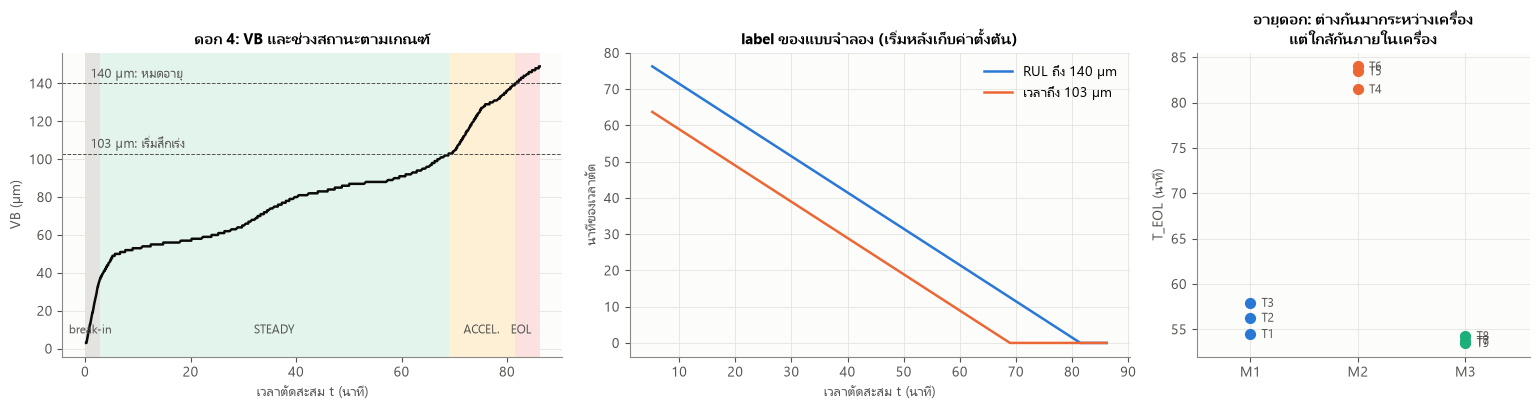

In [20]:
D = R.build_all(runs_raw.drop(columns=["layer", "pos_in_layer"]))
life = pd.DataFrame([dict(tool=t, machine=d.machine, T_acc=d.T_acc, T_eol=d.T_eol, accel_pct=d.T_acc / d.T_eol * 100,
                          first_pred_min=d.t_min[0], n_runs=d.n_runs, n_windows=len(d.X)) for t, d in D.items()]).set_index("tool")
display(life.round(2))
lt = life.groupby("machine").T_eol.agg(["mean", "std", "min", "max"]); lt["CV (%)"] = lt["std"] / lt["mean"] * 100
print("อายุดอก (นาทีของเวลาตัดจนถึง VB = 140 µm) แยกเครื่อง"); display(lt.round(2))

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.2), gridspec_kw={"width_ratios": [1.2, 1.2, 0.8]})
g = runs_raw[runs_raw.tool == 4].sort_values("run"); d = D[4]
tt = g.contact / 60
ax[0].axvspan(0, 170 / 60, color=C["grid"], lw=0); ax[0].axvspan(170 / 60, d.T_acc, color="#e3f4ec", lw=0)
ax[0].axvspan(d.T_acc, d.T_eol, color="#fdf0d5", lw=0); ax[0].axvspan(d.T_eol, tt.max(), color="#fbe1e0", lw=0)
ax[0].plot(tt, g.wear, color=C["ink"])
for v, lab in [(RT.VB_ACCEL, "103 µm: เริ่มสึกเร่ง"), (RT.VB_EOL, "140 µm: หมดอายุ")]:
    ax[0].axhline(v, color=C["ink2"], lw=0.7, ls="--"); ax[0].text(1, v + 3, lab, color=C["ink2"], fontsize=9)
for xx, lab in [(1.0, "break-in"), ((170 / 60 + d.T_acc) / 2, "STEADY"), ((d.T_acc + d.T_eol) / 2, "ACCEL."), (d.T_eol + 1.2, "EOL")]:
    ax[0].text(xx, 8, lab, color=C["ink2"], fontsize=8.5, ha="center")
ax[0].set(xlabel="เวลาตัดสะสม t (นาที)", ylabel="VB (µm)", title="ดอก 4: VB และช่วงสถานะตามเกณฑ์")
ax[1].plot(d.t_min, d.rul, color=C["blue"], label="RUL ถึง 140 µm")
ax[1].plot(d.t_min, d.y[:, 0], color=C["orange"], label="เวลาถึง 103 µm")
ax[1].set(xlabel="เวลาตัดสะสม t (นาที)", ylabel="นาทีของเวลาตัด", title="label ของแบบจำลอง (เริ่มหลังเก็บค่าตั้งต้น)"); ax[1].legend()
for m, gg in life.groupby("machine"):
    ax[2].scatter([m] * len(gg), gg.T_eol, color=MACHINE_COLOR[m], s=50, zorder=3)
    for t_, r_ in gg.iterrows(): ax[2].annotate(f"T{t_}", (m, r_.T_eol), xytext=(8, -3), textcoords="offset points", fontsize=8.5, color=C["ink2"])
ax[2].set(xticks=[1, 2, 3], xticklabels=["M1", "M2", "M3"], ylabel="T_EOL (นาที)", title="อายุดอก: ต่างกันมากระหว่างเครื่อง\nแต่ใกล้กันภายในเครื่อง", xlim=(0.5, 3.6))
fig.tight_layout(); savefig(fig, "r01_labels"); plt.show()

**อ่านผล 3.7:** อายุดอกภายในเครื่องเดียวกันต่างกันเพียง CV 0.7–3% (เงื่อนไขการตัดคงที่) แต่ M2 อายุยาวกว่า M1/M3 ~1.5 เท่า → **หมายเลขเครื่องต้องเป็นอินพุต** และ "อายุเฉลี่ยของเครื่อง" จะเป็นเกณฑ์เปรียบเทียบ (baseline) ที่แข็งมาก ช่วงสึกเร่งเริ่มที่ ~75–85% ของอายุดอก

## 3.8 อินพุตรายรัน, หน้าต่าง 29 รัน และความนิ่งของอินพุต
ทุกรันที่จบ ระบบคำนวณค่าเฉลี่ยในช่วงตัดเสถียรของสัญญาณ 7 ตัว แล้วแปลงเป็น **การเปลี่ยนแปลงจากค่าตั้งต้นของดอก** (มัธยฐานของ 29 รันแรกหลัง break-in — รู้ได้ในโรงงานโดยไม่ต้องวัด VB) ซึ่งตัดผลต่างระดับ/หน่วยระหว่างเครื่องออก:

| อินพุต (12 ตัวต่อรัน) | ที่มา | การแปลง |
|---|---|---|
| `sp_rel` แรงบิด spindle RMS | controller | $x/x_0 - 1$ |
| `ay_rel`, `ax_rel` แรง/แรงบิดมอเตอร์แกนป้อน Y (ทิศตัด), X | controller | $|\bar x|/|\bar x_0| - 1$ |
| `fx_rel`, `fres_rel` แรง Fx, แรงลัพธ์ | dynamometer | $x/x_0 - 1$ |
| `fy_d`, `fz_d` แรง Fy, Fz (ข้ามศูนย์ได้) | dynamometer | $(x - x_0)/F_{res,0}$ |
| `t_hours` เวลาตัดสะสม | controller | ชั่วโมง |
| `m1, m2, m3` เครื่อง | แผนการผลิต | one-hot |
| `x_norm` ตำแหน่งแนวตัด | controller | $(x - 87)/76$ |

อินพุตของแบบจำลอง = **หน้าต่าง 29 รันล่าสุด × 12 ตัว** (29 รัน = 1 ชั้นงาน = 1 คาบฤดูกาลพอดี)

ADF p (level)         ADF p (Δ1Δ29)        ADF p (Δ29)        
feature      fres_rel  sp_rel      fres_rel sp_rel    fres_rel  sp_rel
tool                                                                  
1              0.8781  0.4742           0.0    0.0      0.0046  0.0025
2              0.9967  0.9595           0.0    0.0      0.5133  0.0001
3              0.9656  0.7473           0.0    0.0      0.1892  0.0084
4              1.0000  0.9990           0.0    0.0      0.9964  0.0000
5              0.9652  0.9478           0.0    0.0      0.0002  0.0000
6              1.0000  0.9990           0.0    0.0      0.7914  0.0000
7              0.9686  0.9276           0.0    0.0      0.4702  0.0003
8              0.5246  0.4138           0.0    0.0      0.2880  0.0031
9              0.5308  0.9652           0.0    0.0      0.0121  0.0005

ระดับเดิมไม่นิ่ง (ADF p ≥ 0.05): 18 / 18 | KPSS ปฏิเสธความนิ่ง: 18 / 18 | หลัง Δ1Δ29 นิ่ง: 18 / 18


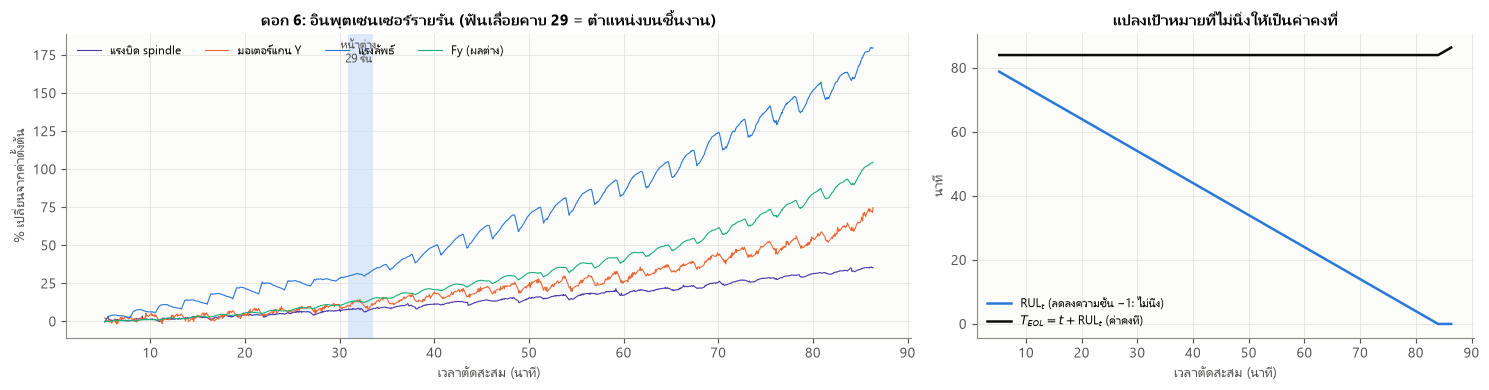

In [21]:
from statsmodels.tsa.stattools import adfuller, kpss
fs_rows = []
warnings.simplefilter("ignore")
for t, d in D.items():
    F = d.X[:, -1, :]                      # ฟีเจอร์ของรันล่าสุดในแต่ละหน้าต่าง = อนุกรมรายรัน
    for j, name in [(0, "sp_rel"), (4, "fres_rel")]:
        x = F[:, j]
        x29 = x[29:] - x[:-29]             # seasonal difference (คาบ 29)
        fs_rows.append(dict(tool=t, feature=name, n=len(x), **{
            "ADF p (level)": adfuller(x, autolag="AIC")[1],
            "KPSS p (level)": kpss(x, regression="c", nlags="auto")[1],
            "ADF p (Δ29)": adfuller(x29, autolag="AIC")[1],
            "ADF p (Δ1Δ29)": adfuller(np.diff(x29), autolag="AIC")[1]}))
fs_tab = pd.DataFrame(fs_rows)   # (KPSS เตือนเมื่อ p < 0.01 = นอกตาราง — ซ่อนไว้)
display(fs_tab.pivot_table(index="tool", columns="feature", values=["ADF p (level)", "ADF p (Δ29)", "ADF p (Δ1Δ29)"]).round(4))
print("ระดับเดิมไม่นิ่ง (ADF p ≥ 0.05):", (fs_tab["ADF p (level)"] >= 0.05).sum(), "/", len(fs_tab),
      "| KPSS ปฏิเสธความนิ่ง:", (fs_tab["KPSS p (level)"] < 0.05).sum(), "/", len(fs_tab),
      "| หลัง Δ1Δ29 นิ่ง:", (fs_tab["ADF p (Δ1Δ29)"] < 0.05).sum(), "/", len(fs_tab))

d = D[6]; F = d.X[:, -1, :]
fig, ax = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={"width_ratios": [1.7, 1]})
for j, name, col in [(0, "แรงบิด spindle", C["violet"]), (1, "มอเตอร์แกน Y", C["orange"]), (4, "แรงลัพธ์", C["blue"]), (5, "Fy (ผลต่าง)", C["aqua"])]:
    ax[0].plot(d.t_min, F[:, j] * 100, color=col, lw=0.8, label=name)
w0 = 300
ax[0].axvspan(d.t_min[w0 - 28], d.t_min[w0], color=C["band"], alpha=0.7, lw=0)
ax[0].text(d.t_min[w0 - 14], ax[0].get_ylim()[1] * 0.9, "หน้าต่าง\n29 รัน", ha="center", fontsize=8.5, color=C["ink2"])
ax[0].set(xlabel="เวลาตัดสะสม (นาที)", ylabel="% เปลี่ยนจากค่าตั้งต้น", title="ดอก 6: อินพุตเซนเซอร์รายรัน (ฟันเลื่อยคาบ 29 = ตำแหน่งบนชิ้นงาน)")
ax[0].legend(ncol=4, loc="upper left", fontsize=8.5)
Teol_hat = d.t_min + d.rul
ax[1].plot(d.t_min, d.rul, color=C["blue"], label="RUL$_t$ (ลดลงความชัน −1: ไม่นิ่ง)")
ax[1].plot(d.t_min, Teol_hat, color=C["ink"], label="$T_{EOL} = t + $RUL$_t$ (ค่าคงที่)")
ax[1].set(xlabel="เวลาตัดสะสม (นาที)", ylabel="นาที", title="แปลงเป้าหมายที่ไม่นิ่งให้เป็นค่าคงที่"); ax[1].legend(fontsize=8.5)
fig.tight_layout(); savefig(fig, "r02_inputs_window"); plt.show()

**อ่านผล 3.8:**
- อินพุตเซนเซอร์รายรัน **ไม่นิ่งที่ระดับเดิม** (trend จากการสึก + ฤดูกาลคาบ 29) แต่หลัง **seasonal difference (Δ29) ตามด้วย first difference** นิ่งทุกดอก → อนุกรมเป็นแบบ "trend + ฤดูกาลเชิงตำแหน่ง" ตรงกับ 3.1–3.2 แบบจำลองจึงรับ *หน้าต่างเต็มคาบ* + ตำแหน่ง x แทนการ differencing เอง เพื่อไม่ทิ้งข้อมูลระดับ (ระดับการเปลี่ยนแปลงสะสมคือข้อมูลการสึก)
- **เป้าหมาย RUL$_t$ = $T_{EOL} - t$ ไม่นิ่งโดยนิยาม** (trend เชิงกำหนดความชัน −1) แต่ $T_{EOL}$ เป็น **ค่าคงที่ต่อดอก** → ข้อจำกัดฟิสิกส์ของระบบ: แปลงค่าพยากรณ์ทุกรันเป็น $\hat T_{EOL,t} = t + \widehat{\text{RUL}}_t$ แล้วประมาณค่าคงที่นี้ด้วยมัธยฐานของทุกค่าที่ผ่านมา (`EOLTracker`) RUL ที่รายงาน = $\max(\tilde T_{EOL} - t, 0)$ จึงลดลง 1 นาทีต่อเวลาตัด 1 นาทีตามธรรมชาติ ไม่แกว่งขึ้นลงตามสัญญาณรายรัน

## 3.9 การแบ่งข้อมูล Train / Test
อนุกรมเวลาห้ามสุ่มแบ่ง และ label RUL ของรันต้น ๆ ต้องรู้เวลาหมดอายุของดอก (อนาคต) จึงแบ่ง **ตามดอก** และ **ตามเวลา**:
1. **ดอกฝึก/ดอกทดสอบ (production):** ฝึกแบบจำลองที่ใช้งานจริงด้วย T1, T2, T4, T5, T7, T8 (เครื่องละ 2 ดอก) และ **สงวน T3, T6, T9** ไว้เป็นข้อมูลสตรีมบนเว็บ (ไม่เคยถูกใช้ฝึก เลือกโครงสร้าง หรือปรับเทียบช่วงความเชื่อมั่น)
2. **Leave-one-tool-out (LOTO) 9 รอบ:** เปรียบเทียบแบบจำลองอย่างยุติธรรม — ดอกทดสอบไม่มีข้อมูลใดของตัวเองถูกใช้ฝึก
3. **80 : 20 ตามเวลาภายในแต่ละดอก:** อนุกรมที่ติดตามของดอกทดสอบแบ่งเป็น 80% แรก (ประวัติ) และ **20% ท้าย = ช่วงทดสอบหลัก** ซึ่งเป็นช่วงที่ต้องตัดสินใจเปลี่ยนดอก (รายงานทั้ง MAE ทั้งอายุ และ MAE 20% ท้าย)

,machine,role,n_runs,n_predicted,n_first80,n_last20,t_split_min,T_eol
tool,,,,,,,,
1,1,ฝึก production,609,552,442,110,47.38,54.50
2,1,ฝึก production,609,552,442,110,46.83,56.29
3,1,สตรีมบนเว็บ (held-out),638,581,465,116,50.07,57.93
4,2,ฝึก production,928,871,697,174,70.20,81.48
5,2,ฝึก production,928,871,697,174,70.18,83.47
6,2,สตรีมบนเว็บ (held-out),928,871,697,174,70.47,84.00
7,3,ฝึก production,609,552,442,110,47.13,53.73
8,3,ฝึก production,560,532,426,106,48.15,54.27
9,3,สตรีมบนเว็บ (held-out),609,552,442,110,47.27,53.50


รวม: ช่วง 80% แรก 4750 รัน | ช่วงทดสอบ 20% ท้าย 1184 รัน (20.0%)


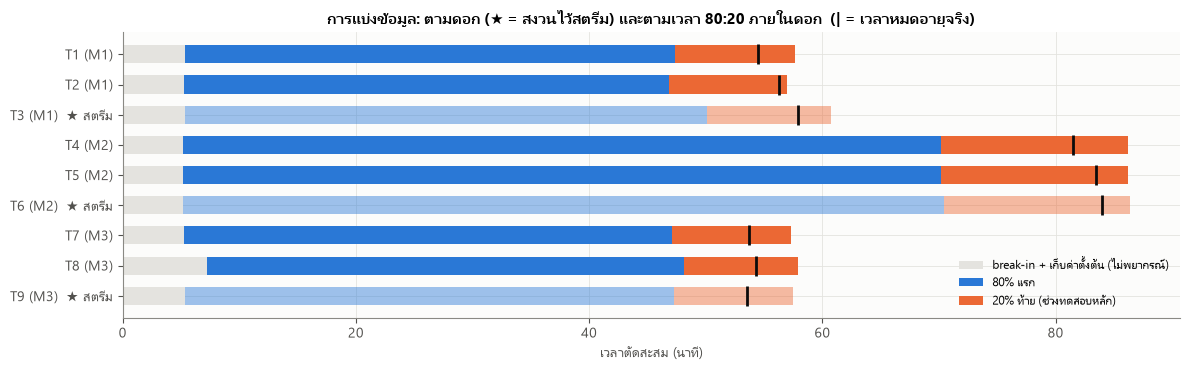

In [22]:
split = pd.DataFrame([dict(tool=t, machine=d.machine, role="สตรีมบนเว็บ (held-out)" if t in X.STREAM_TOOLS else "ฝึก production",
                           n_runs=d.n_runs, n_predicted=len(d.t_min), n_first80=d.n80, n_last20=len(d.t_min) - d.n80,
                           t_split_min=d.t_min[d.n80], T_eol=d.T_eol) for t, d in D.items()]).set_index("tool")
display(split.round(2))
print("รวม: ช่วง 80% แรก", split.n_first80.sum(), "รัน | ช่วงทดสอบ 20% ท้าย", split.n_last20.sum(), "รัน",
      f"({split.n_last20.sum() / split.n_predicted.sum():.1%})")
fig, ax = plt.subplots(figsize=(12, 3.8))
for i, (t, d) in enumerate(D.items()):
    held = t in X.STREAM_TOOLS
    ax.barh(i, d.t_min[0], color=C["grid"], height=0.6, label="break-in + เก็บค่าตั้งต้น (ไม่พยากรณ์)" if i == 0 else None)
    ax.barh(i, d.t_min[d.n80] - d.t_min[0], left=d.t_min[0], color=C["blue"], height=0.6, alpha=0.45 if held else 1,
            label="80% แรก" if i == 0 else None)
    ax.barh(i, d.t_min[-1] - d.t_min[d.n80], left=d.t_min[d.n80], color=C["orange"], height=0.6, alpha=0.45 if held else 1,
            label="20% ท้าย (ช่วงทดสอบหลัก)" if i == 0 else None)
    ax.plot(d.T_eol, i, "|", color=C["ink"], ms=14, mew=2)
ax.set_yticks(range(9), [f"T{t} (M{d.machine}){'  ★ สตรีม' if t in X.STREAM_TOOLS else ''}" for t, d in D.items()]); ax.invert_yaxis()
ax.set(xlabel="เวลาตัดสะสม (นาที)", title="การแบ่งข้อมูล: ตามดอก (★ = สงวนไว้สตรีม) และตามเวลา 80:20 ภายในดอก  (| = เวลาหมดอายุจริง)")
ax.legend(loc="lower right", fontsize=8.5); fig.tight_layout(); savefig(fig, "r03_split"); plt.show()

---
# 4. การเปรียบเทียบแบบจำลองการพยากรณ์ (อินพุตไม่มี VB)

## 4.1 จากลักษณะข้อมูล → ข้อกำหนดของแบบจำลอง
| ลักษณะที่พบ (หัวข้อ) | ข้อกำหนด |
|---|---|
| VB/อินพุตมี trend ทางเดียว ไม่นิ่ง (3.1, 3.4, 3.8) | ต้องเรียนจาก *ระดับสะสม* ไม่ใช่แค่การเปลี่ยนแปลงสั้น ๆ |
| ฤดูกาลเชิงตำแหน่งคาบ 29 รัน (3.2) | หน้าต่างอินพุต ≥ 1 คาบ + ตำแหน่ง x |
| การเปลี่ยนระบอบที่ VB ≈ 103 µm (3.6) | ต้องแทนพลวัตไม่เชิงเส้น/หลายระบอบได้ |
| อายุต่างกันตามเครื่องมาก แต่ใกล้กันภายในเครื่อง (3.7) | ต้องมีหมายเลขเครื่อง และต้องชนะ baseline "อายุเฉลี่ยของเครื่อง" |
| มีเพียง 9 ดอก (ข้อมูลน้อยในระดับดอก) | ต้องกัน overfit กับลายเซ็นของดอกฝึก และเลือกโครงสร้างแบบ nested |
| เป้าหมาย RUL$_t$ = $T_{EOL} - t$, $T_{EOL}$ คงที่ (3.8) | บังคับข้อจำกัดฟิสิกส์ให้ RUL ลดลงตามเวลาอย่างสม่ำเสมอ |

## 4.2 แบบจำลองที่เปรียบเทียบ (3 แบบ)
1. **Fleet reference (baseline):** $\widehat{\text{RUL}}_t = \overline{T}_{EOL}(\text{เครื่อง}) - t$ — ใช้เวลาตัด + เครื่องเท่านั้น (สิ่งที่โรงงานทำได้โดยไม่มี AI)
2. **StateSpace (ทางอ้อม: พยากรณ์ VB ก่อน):** VB เป็นสถานะแฝงที่เพิ่มแบบ Gamma ตามเส้นทางการสึกอ้างอิงของเครื่อง × ตัวคูณประจำดอก κ, สังเกต "VB เสมือน" จาก soft sensor (Ridge บน health indicator รายชั้น) ด้วย particle filter 4,000 อนุภาค → เวลาที่เส้นทาง VB เฉลี่ยข้าม 103/140 µm (อัปเดตทุกชั้นงาน)
3. **GRU direct-RUL (ที่เสนอ):** GRU 1 ชั้น (hidden 32) อ่านหน้าต่าง 29 รัน × 12 อินพุต → หัวเชิงเส้น 2 ค่า [เวลาถึง 103 µm, เวลาถึง 140 µm] ผ่าน softplus (ไม่ติดลบ) · loss = L1(EOL) + 0.5·L1(ACC) · Adam 30 epochs · ensemble 3 ตัว (production 5 ตัว) · **สัญญาณรบกวนเสริม σ = 1 (หน่วย std) บนอินพุตเซนเซอร์ตอนฝึก** เพื่อไม่ให้จำลายเซ็นเฉพาะของดอกฝึก · ตามด้วย **ข้อจำกัดฟิสิกส์ EOLTracker** และช่วง P10–P90 จากความคลาดเคลื่อน LOTO

สมการ GRU: $r_t=\sigma(W_r x_t + U_r h_{t-1})$, $z_t=\sigma(W_z x_t + U_z h_{t-1})$, $\tilde h_t=\tanh(W_h x_t + r_t\odot U_h h_{t-1})$, $h_t=(1-z_t)\odot\tilde h_t + z_t\odot h_{t-1}$, $\widehat{\text{RUL}} = 20\cdot\mathrm{softplus}(W_o h_{29})$

## 4.3 โปรโตคอลกัน "จูนกับชุดทดสอบ"
1. **Nested selection:** เลือกรูปแบบ GRU จาก 4 ตัวเลือก ด้วย LOTO *ภายในดอกฝึก production 6 ดอกเท่านั้น* (ไม่แตะ T3/T6/T9) เกณฑ์: MAE ทั้งอายุต่ำสุด โดย % พยากรณ์เกินจริง > 1 ชั้นในช่วง 20% ท้าย ≤ 1%
2. **LOTO 9 ดอก:** เปรียบเทียบ 3 แบบจำลอง + ablation ของอินพุต
3. **Held-out สตรีม:** แบบจำลอง production ที่ส่งออกจริง เล่นกับ T3/T6/T9 ผ่านโค้ด runtime เดียวกับ backend (หัวข้อ 6)

In [23]:
if RUN_EXPERIMENTS:
    X.main()
sel = pd.read_csv(RES / "nested_selection.csv")
met = pd.read_csv(RES / "loto_metrics.csv"); stt = pd.read_csv(RES / "loto_state.csv")
dec = pd.read_csv(RES / "loto_decisions.csv"); pr = pd.read_csv(RES / "loto_per_run.csv.gz")
lomo = pd.read_csv(RES / "lomo_metrics.csv")
cols = ["MAE_all", "MAE_test20", "Late_pct_test20"]
seltab = sel.groupby("variant")[cols].mean()
seltab.index = seltab.index.map({"direct": "direct (เรียน RUL ตรง)", "direct+noise": "direct + noise σ=1",
                                 "prior": "prior (ปรับแก้อายุอ้างอิงเครื่อง ±10%)", "prior+noise": "prior + noise",
                                 "(Fleet reference)": "(Fleet reference)"})
print("4.4 Nested selection — LOTO ภายในดอกฝึก 6 ดอก (นาทีของเวลาตัด)"); display(seltab.round(3))

4.4 Nested selection — LOTO ภายในดอกฝึก 6 ดอก (นาทีของเวลาตัด)


,MAE_all,MAE_test20,Late_pct_test20
variant,,,
(Fleet reference),1.368,1.091,0.000
direct (เรียน RUL ตรง),2.044,1.735,5.503
direct + noise σ=1,1.327,1.063,0.000
prior (ปรับแก้อายุอ้างอิงเครื่อง ±10%),1.351,1.082,0.000
prior + noise,1.358,1.081,0.000


## 4.4 ผลการเลือกแบบ nested
GRU ที่เรียน RUL ตรง ๆ **โดยไม่มี noise** จำลายเซ็นของดอกฝึกจนแย่กว่า baseline มาก (MAE 2.04 นาที, พยากรณ์เกินจริง 5.5%) เมื่อเพิ่มสัญญาณรบกวนเสริมบนอินพุตเซนเซอร์ ความคลาดลดเหลือ 1.33 นาทีและไม่มีการพยากรณ์เกินจริงเลย → **เลือก `direct+noise`** (การเลือกนี้ไม่ใช้ดอกที่สงวนไว้)

## 4.5 ผลแบบ leave-one-tool-out (9 ดอก)

,MAE ทั้งอายุ,MAE 20% ท้าย,RMSE 20% ท้าย,Bias 20% ท้าย,% เกินจริง>1 ชั้น (20% ท้าย),% เกินจริง>1 ชั้น (ทั้งอายุ)
Fleet reference (อายุเฉลี่ยของเครื่อง),1.159,0.895,1.024,0.050,0.000,0.000
GRU direct-RUL (เซนเซอร์+เวลา+เครื่อง),1.112,0.913,1.053,-0.189,0.000,0.000
GRU ไม่ระบุเครื่อง,4.888,0.925,1.097,-0.138,0.000,32.406
GRU ไม่มีเซนเซอร์,1.312,0.944,1.085,-0.196,0.000,0.000
StateSpace (VB แฝง → จุดตัดเกณฑ์),1.585,1.753,1.988,0.045,13.343,14.712
GRU[full] — ไม่มีข้อจำกัดฟิสิกส์,1.278,1.275,1.443,-0.222,0.000,0.026
GRU[sensors+time] — ไม่มีข้อจำกัดฟิสิกส์,3.467,1.457,1.667,-0.123,6.322,19.238
GRU[time+machine] — ไม่มีข้อจำกัดฟิสิกส์,1.319,1.159,1.277,0.213,6.667,2.355


MAE 20% ท้าย รายดอก (นาที)


,T1,T2,T3,T4,T5,T6,T7,T8,T9
model,,,,,,,,,
Fleet reference (อายุเฉลี่ยของเครื่อง),2.11,0.07,1.55,1.73,0.58,1.22,0.10,0.38,0.32
GRU direct-RUL (เซนเซอร์+เวลา+เครื่อง),1.40,0.89,1.49,1.52,0.76,1.19,0.63,0.08,0.25
GRU ไม่ระบุเครื่อง,0.31,1.12,0.21,1.57,1.46,0.48,1.52,0.56,1.10
GRU ไม่มีเซนเซอร์,1.88,0.31,1.62,1.41,0.96,1.60,0.20,0.45,0.08
StateSpace (VB แฝง → จุดตัดเกณฑ์),1.73,1.00,0.86,0.79,2.40,0.65,1.98,2.33,4.04


Wilcoxon GRU[full] vs Fleet (MAE_all): p = 0.496 | GRU ดีกว่าใน 6/9 ดอก
Wilcoxon GRU[full] vs Fleet (MAE_test20): p = 0.820 | GRU ดีกว่าใน 6/9 ดอก


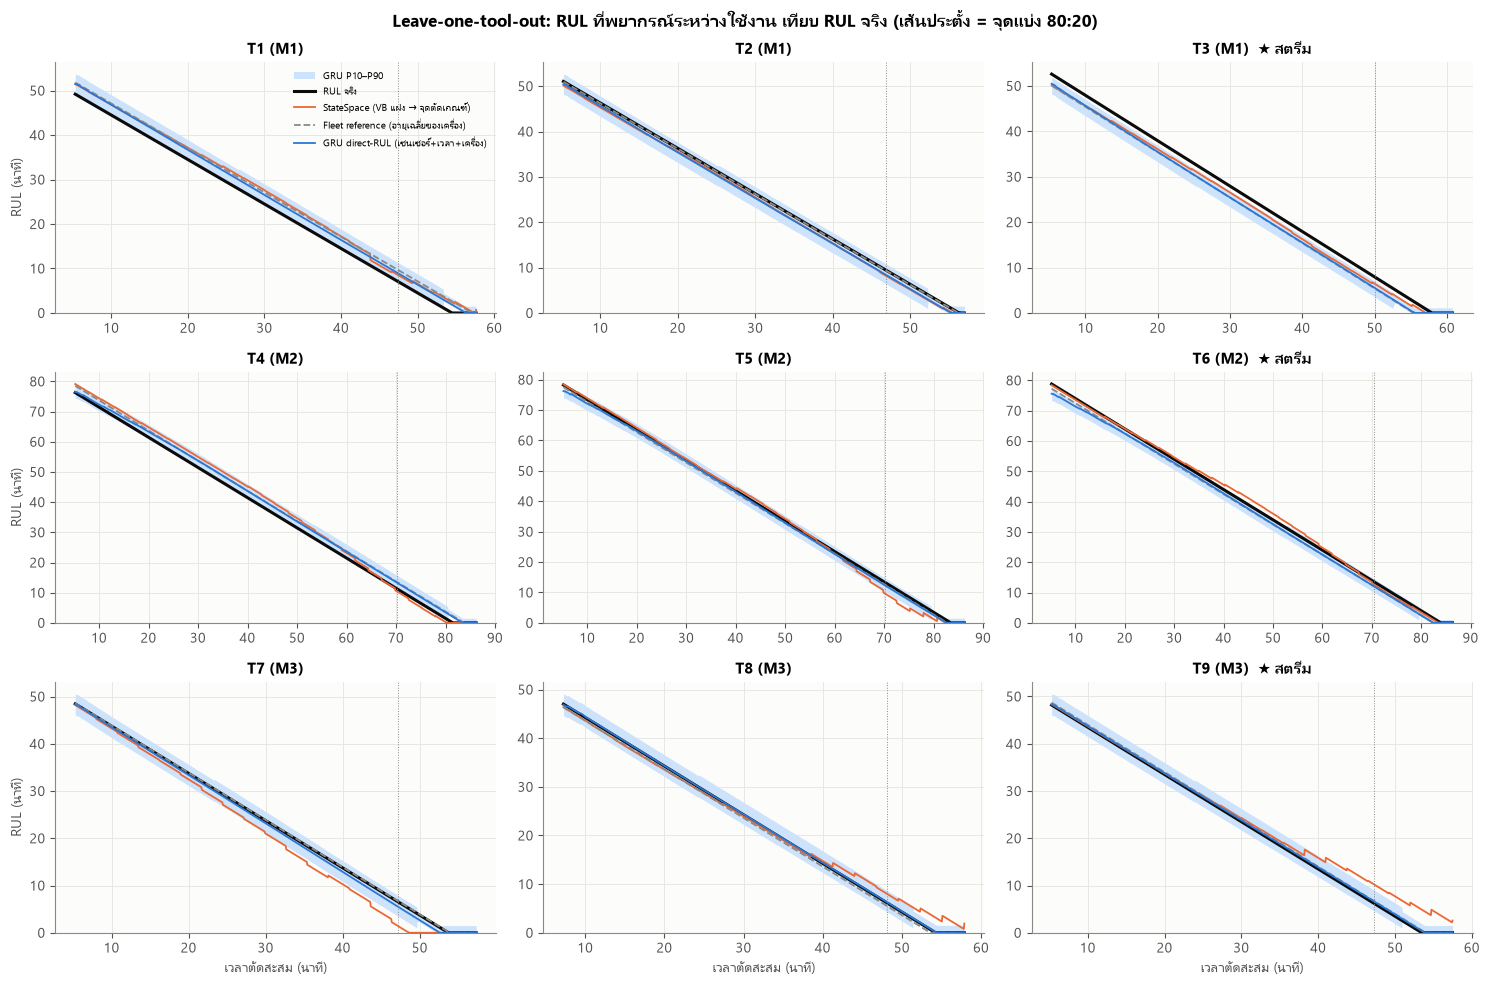

In [24]:
sm = met[met.output == "smooth"].groupby("model")[["MAE_all", "MAE_test20", "RMSE_test20", "Bias_test20", "Late_pct_test20", "Late_pct_all"]].mean()
raw = met[met.output == "raw"].groupby("model")[["MAE_all", "MAE_test20", "RMSE_test20", "Bias_test20", "Late_pct_test20", "Late_pct_all"]].mean()
raw.index = [f"{i} — ไม่มีข้อจำกัดฟิสิกส์" for i in raw.index]
tab = pd.concat([sm, raw]).rename(index=lambda i: MODEL_NAME.get(i, i))
tab.columns = ["MAE ทั้งอายุ", "MAE 20% ท้าย", "RMSE 20% ท้าย", "Bias 20% ท้าย", "% เกินจริง>1 ชั้น (20% ท้าย)", "% เกินจริง>1 ชั้น (ทั้งอายุ)"]
display(tab.round(3))
per_tool = met[met.output == "smooth"].pivot(index="model", columns="tool", values="MAE_test20").rename(index=MODEL_NAME)
per_tool.columns = [f"T{c}" for c in per_tool.columns]
print("MAE 20% ท้าย รายดอก (นาที)"); display(per_tool.round(2))
# Wilcoxon: GRU vs Fleet รายดอก
a_ = met[(met.output == "smooth") & (met.model == "GRU[full]")].sort_values("tool")
b_ = met[(met.output == "smooth") & (met.model == "Fleet")].sort_values("tool")
for c_ in ["MAE_all", "MAE_test20"]:
    print(f"Wilcoxon GRU[full] vs Fleet ({c_}): p = {stats.wilcoxon(a_[c_].values, b_[c_].values).pvalue:.3f}",
          f"| GRU ดีกว่าใน {(a_[c_].values < b_[c_].values).sum()}/9 ดอก")

fig, axs = plt.subplots(3, 3, figsize=(15, 10), sharey=False)
for ax, t in zip(axs.ravel(), sorted(D)):
    g = pr[pr.tool == t]
    gg = g[g.model == "GRU[full]"]
    ax.fill_between(gg.t_min, gg.rul_lo, gg.rul_hi, color=C["band"], lw=0, label="GRU P10–P90")
    ax.plot(gg.t_min, gg.rul_true, color=C["ink"], lw=2.2, label="RUL จริง")
    for m_, ls in [("StateSpace", "-"), ("Fleet", "--"), ("GRU[full]", "-")]:
        h = g[g.model == m_]; ax.plot(h.t_min, h.rul, color=MODEL_COLOR[m_], lw=1.3, ls=ls, label=MODEL_NAME[m_])
    ax.axvline(D[t].t_min[D[t].n80], color=C["muted"], lw=0.7, ls=":")
    ax.set_title(f"T{t} (M{D[t].machine}){'  ★ สตรีม' if t in X.STREAM_TOOLS else ''}"); ax.set_ylim(bottom=0)
for ax in axs[-1]: ax.set_xlabel("เวลาตัดสะสม (นาที)")
for ax in axs[:, 0]: ax.set_ylabel("RUL (นาที)")
axs[0, 0].legend(fontsize=7.5, loc="upper right")
fig.suptitle("Leave-one-tool-out: RUL ที่พยากรณ์ระหว่างใช้งาน เทียบ RUL จริง (เส้นประตั้ง = จุดแบ่ง 80:20)", fontweight="bold")
fig.tight_layout(); savefig(fig, "r04_loto_trajectories"); plt.show()

**อ่านผล 4.5:**
- **GRU direct-RUL (เซนเซอร์ + เวลา + เครื่อง) แม่นที่สุดตลอดอายุ** (MAE ≈ 1.11 นาที เทียบ Fleet 1.16 และ StateSpace 1.58) และ **ไม่เคยพยากรณ์อายุเกินจริงเกิน 1 ชั้นงาน** ในช่วงตัดสินใจ ส่วนช่วง 20% ท้าย GRU กับ Fleet ใกล้เคียงกัน (0.91 vs 0.90 นาที — ต่างกันไม่มีนัยสำคัญด้วยข้อมูล 9 ดอก)
- **StateSpace (ทางอ้อม) แย่ที่สุดในช่วงท้าย** (MAE 1.75, เกินจริง 13% ของรัน): ต้องผ่าน VB เสมือนจาก soft sensor ซึ่งมีความเอียงต่างกันรายดอก ความคลาดของ VB ใกล้เกณฑ์ขยายเป็นความคลาดของเวลาข้ามเกณฑ์ และอัปเดตได้เพียงทุกชั้นงาน → **การเรียน RUL โดยตรงดีกว่าการพยากรณ์ VB แล้วหาจุดตัด** สำหรับข้อมูลชุดนี้
- Fleet reference แข็งมากเพราะอายุดอกในเครื่องเดียวกันต่างกันเพียง 1–3% (เงื่อนไขการตัดคงที่) — ประโยชน์ของ GRU อยู่ที่ (ก) ใช้ข้อมูลของดอกนั้นเองปรับค่าประมาณได้ (ช่วงท้ายดีกว่า Fleet ใน 6/9 ดอก เช่น T1, T4, T8 แต่แย่กว่าใน T2, T5, T7) (ข) ให้ช่วงความเชื่อมั่น/สถานะ และ (ค) ใช้ได้เมื่อเงื่อนไขการตัดเปลี่ยน ซึ่ง baseline ทำไม่ได้

## 4.6 ผลของข้อจำกัดฟิสิกส์ (T_EOL คงที่) และการเลือกอินพุต

Late_pct_test20        MAE_all        MAE_test20       
output                        raw smooth     raw smooth        raw smooth
model                                                                    
GRU[full]                   0.000    0.0   1.278  1.112      1.275  0.913
GRU[sensors+time]           6.322    0.0   3.467  4.888      1.457  0.925
GRU[time+machine]           6.667    0.0   1.319  1.312      1.159  0.944

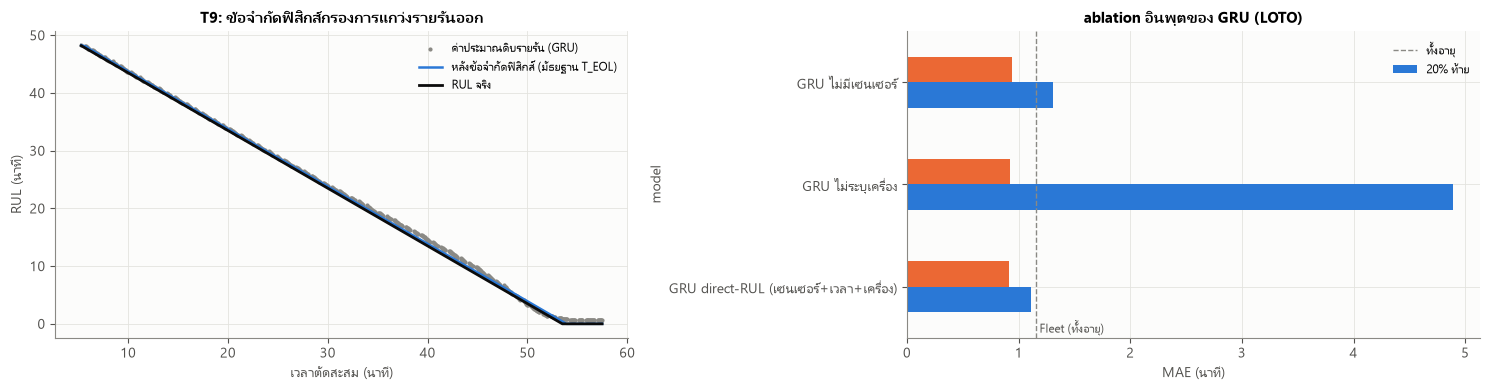

In [25]:
abl = met[met.model.str.startswith("GRU")].pivot_table(index="model", columns="output", values=["MAE_all", "MAE_test20", "Late_pct_test20"]).round(3)
display(abl)
g = pr[(pr.tool == 9) & (pr.model == "GRU[full]")]
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].scatter(g.t_min, g.rul_raw, s=4, color=C["muted"], label="ค่าประมาณดิบรายรัน (GRU)")
ax[0].plot(g.t_min, g.rul, color=C["blue"], label="หลังข้อจำกัดฟิสิกส์ (มัธยฐาน T_EOL)")
ax[0].plot(g.t_min, g.rul_true, color=C["ink"], lw=2, label="RUL จริง")
ax[0].set(xlabel="เวลาตัดสะสม (นาที)", ylabel="RUL (นาที)", title="T9: ข้อจำกัดฟิสิกส์กรองการแกว่งรายรันออก"); ax[0].legend(fontsize=8.5)
mm = met[(met.output == "smooth") & met.model.str.startswith("GRU")].groupby("model")[["MAE_all", "MAE_test20"]].mean()
mm.rename(index=MODEL_NAME).plot.barh(ax=ax[1], color=[C["blue"], C["orange"]])
ax[1].axvline(met[(met.model == "Fleet")].MAE_all.mean(), color=C["muted"], ls="--", lw=1); ax[1].text(met[(met.model == "Fleet")].MAE_all.mean(), -0.45, " Fleet (ทั้งอายุ)", color=C["ink2"], fontsize=8.5)
ax[1].set(xlabel="MAE (นาที)", title="ablation อินพุตของ GRU (LOTO)"); ax[1].legend(["ทั้งอายุ", "20% ท้าย"], fontsize=8.5)
fig.tight_layout(); savefig(fig, "r05_physics_ablation"); plt.show()

**อ่านผล 4.6:**
- ข้อจำกัดฟิสิกส์ลด MAE ทั้งอายุของ GRU จาก 1.28 → 1.11 นาที และช่วงท้าย 1.27 → 0.91 นาที โดยไม่ต้องฝึกใหม่ (เป็นการประมาณค่าคงที่ $T_{EOL}$ ด้วยมัธยฐาน ซึ่งทนต่อรันผิดปกติ)
- **เซนเซอร์ช่วยจริงเมื่อฝึกอย่างถูกวิธี:** GRU ที่มีเซนเซอร์ (1.11) ดีกว่า GRU ที่มีแค่เวลา + เครื่อง (1.31) ส่วน GRU ที่ไม่รู้ว่าเป็นเครื่องใด (เซนเซอร์ + เวลา) แย่ที่สุดในช่วงต้นอายุ (4.9) — ยืนยันว่าเครื่องเป็นข้อมูลสำคัญและเซนเซอร์เป็น *ตัวปรับแก้* รายดอก

## 4.7 การจำแนกสถานะการสึก (STEADY / ACCELERATED / END_OF_LIFE)
สถานะไม่ได้มาจากหัวจำแนกแยก แต่ **อนุมานจากเวลาถึงเกณฑ์ทั้งสองที่ผ่านข้อจำกัดฟิสิกส์แล้ว** จึงสอดคล้องกับ RUL เสมอ (ไม่มีกรณี RUL = 0 แต่บอกว่า STEADY)

,acc,macroF1
model,,
Fleet reference (อายุเฉลี่ยของเครื่อง),0.944,0.881
GRU direct-RUL (เซนเซอร์+เวลา+เครื่อง),0.936,0.865
GRU ไม่ระบุเครื่อง,0.930,0.857
GRU ไม่มีเซนเซอร์,0.941,0.868
StateSpace (VB แฝง → จุดตัดเกณฑ์),0.894,0.751


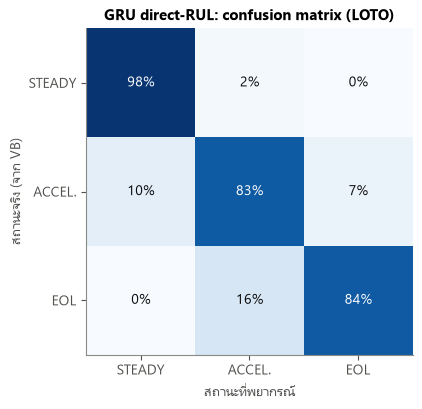

In [26]:
display(stt.groupby("model")[["acc", "macroF1"]].mean().rename(index=MODEL_NAME).round(3))
g = pr[pr.model == "GRU[full]"]
cm = pd.crosstab(g.state_true, g.state, normalize="index").reindex(index=R.STATES, columns=R.STATES).fillna(0)
fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.imshow(cm.values, cmap="Blues", vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm.values[i, j]:.0%}", ha="center", va="center", color="white" if cm.values[i, j] > 0.5 else C["ink"])
ax.set_xticks(range(3), ["STEADY", "ACCEL.", "EOL"]); ax.set_yticks(range(3), ["STEADY", "ACCEL.", "EOL"])
ax.set(xlabel="สถานะที่พยากรณ์", ylabel="สถานะจริง (จาก VB)", title="GRU direct-RUL: confusion matrix (LOTO)"); ax.grid(False)
fig.tight_layout(); savefig(fig, "r06_state_confusion"); plt.show()

**อ่านผล 4.7:** GRU จำแนกสถานะถูก ~94% ของรัน (macro-F1 0.87) ใกล้เคียง Fleet และดีกว่า StateSpace (89%, 0.75) ความผิดพลาดเกือบทั้งหมดอยู่ที่ *รอยต่อ* ระหว่างสถานะ (บอกว่าสึกเร่งเร็วหรือช้ากว่าจริงไม่กี่นาที) ไม่มีการสลับข้ามสองขั้น

## 4.8 เครื่องใหม่ที่ไม่มีประวัติ (leave-one-machine-out)

In [27]:
lt_ = lomo.groupby("model")[["MAE_all", "MAE_test20", "Late_pct_test20"]].mean()
display(lt_.round(2))

,MAE_all,MAE_test20,Late_pct_test20
model,,,
Fleet (ทุกเครื่อง),16.57,10.66,66.67
GRU[sensors+time],23.80,18.01,66.67
GRU[time],18.96,14.26,66.67


**อ่านผล 4.8:** เมื่อเครื่องไม่เคยอยู่ในข้อมูลฝึก ทุกวิธีคลาดมาก (MAE ทั้งอายุ 17–24 นาที) เพราะอายุดอกถูกกำหนดด้วยเครื่องเป็นหลัก: ทดสอบ M1/M3 ด้วยแบบจำลองที่มี M2 (อายุยาว) ในข้อมูลฝึก → พยากรณ์อายุเกินจริง (จึงมีรันที่เกินจริง 2 ใน 3 เครื่อง) ส่วนทดสอบ M2 → พยากรณ์ต่ำกว่าจริง และเซนเซอร์อย่างเดียวบอกไม่ได้ว่าเครื่องใหม่จะทำให้ดอกอายุยืนเท่าใด — **ข้อจำกัดสำคัญ:** ก่อนใช้กับเครื่องใหม่ต้องเก็บข้อมูลดอกแรก ๆ จนหมดอายุ (พร้อมวัด VB) อย่างน้อย 1–2 ดอก

## 4.9 หลักเกณฑ์การเลือกแบบจำลอง
| เกณฑ์ | Fleet reference | StateSpace | **GRU direct-RUL** |
|---|---|---|---|
| ความแม่นทั้งอายุ (MAE, นาที) | 1.16 | 1.58 | **1.11** |
| ความแม่นช่วงตัดสินใจ 20% ท้าย | **0.90** | 1.75 | 0.91 |
| ความปลอดภัย: % พยากรณ์เกินจริง > 1 ชั้น | 0 | 13.3 | **0** |
| ใช้ข้อมูลของดอกนั้นเอง (เซนเซอร์) | ไม่ | ใช่ (ผ่าน VB เสมือน) | **ใช่ (โดยตรง)** |
| อัปเดตทุกรัน / ช่วงความเชื่อมั่น / สถานะ | ไม่ / ไม่ / ไม่ | ทุกชั้น / มี / มี | **ทุกรัน / มี / มี** |
| สอดคล้องฟิสิกส์ (RUL ลดลงตามเวลา) | ใช่ | ใช่ | ใช่ (EOLTracker) |
| ต้องวัด VB ตอนใช้งาน | ไม่ | ไม่ | ไม่ |
| ความซับซ้อนตอนใช้งาน | ต่ำ | สูง (particle filter) | ต่ำ (numpy ~1.6 ms/รัน, 4,482 พารามิเตอร์/ตัว) |

**เลือก GRU direct-RUL** — แม่นที่สุดตลอดอายุ ปลอดภัยเท่า baseline ใช้ข้อมูลเซนเซอร์ของดอกนั้นเอง และให้ข้อมูลประกอบการตัดสินใจครบ โดยตระหนักว่าในชุดข้อมูลที่เงื่อนไขการตัดคงที่ ข้อได้เปรียบเหนือ baseline ยังเล็ก

---
# 5. การวิเคราะห์และสรุปผล

## 5.1 ผลการพยากรณ์ช่วยการตัดสินใจอย่างไร — ย้อนเล่นนโยบายเปลี่ยนดอก
นโยบายของระบบ: **REPLACE_NOW** เมื่อค่าล่าง P10 ของ RUL ≤ 1 ชั้นงาน (2.73 นาที) หรือสถานะ END_OF_LIFE · **PLAN_REPLACEMENT** เมื่อ P10 ≤ 3 ชั้น (8.2 นาที) · **WATCH** เมื่อเข้าช่วงสึกเร่ง
เทียบกับนโยบาย **fixed-life** ที่โรงงานทำได้โดยไม่มี AI: เปลี่ยนเมื่อเวลาตัดถึงอายุ *สั้นที่สุด* ของดอกอื่นบนเครื่องเดียวกัน − 1 ชั้น (ช่วงความเชื่อมั่นของ P10 สำหรับแต่ละแบบจำลองคำนวณจากดอกอื่นเท่านั้น)

,เปลี่ยนช้าเกินเกณฑ์,margin_เฉลี่ย_นาที,margin_ต่ําสุด,ใช้อายุดอก_pct,แจ้งวางแผนล่วงหน้า_นาที
model,,,,,
Fixed-life,0,3.48,0.75,94.46,NaN
Fleet reference (อายุเฉลี่ยของเครื่อง),0,5.19,2.00,91.68,10.65
GRU direct-RUL (เซนเซอร์+เวลา+เครื่อง),0,4.89,2.32,92.11,10.39
GRU ไม่ระบุเครื่อง,0,4.93,2.25,92.01,10.07
GRU ไม่มีเซนเซอร์,0,5.25,2.00,91.62,10.67
StateSpace (VB แฝง → จุดตัดเกณฑ์),0,7.02,0.25,89.06,11.69


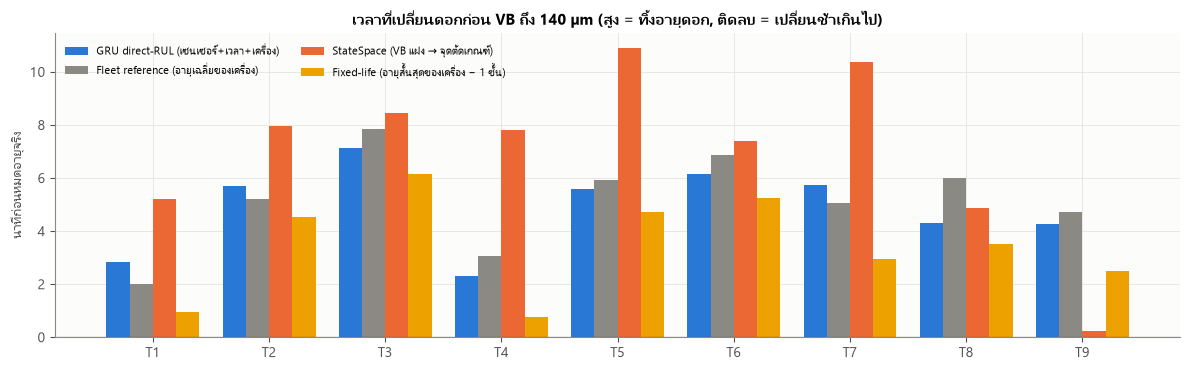

In [28]:
fixed = []
for t, d in D.items():
    others = [D[o].T_eol for o in D if o != t and D[o].machine == d.machine]
    t_rep = min(others) - RT.LAYER_MIN
    fixed.append(dict(tool=t, machine=d.machine, T_eol_true=d.T_eol, t_replace=t_rep, margin_min=d.T_eol - t_rep, late=t_rep > d.T_eol, model="Fixed-life"))
dd = pd.concat([dec, pd.DataFrame(fixed)], ignore_index=True)
dd["life_used_pct"] = dd.t_replace / dd.T_eol_true * 100
summary = dd.groupby("model").agg(เปลี่ยนช้าเกินเกณฑ์=("late", "sum"), margin_เฉลี่ย_นาที=("margin_min", "mean"),
                                  margin_ต่ำสุด=("margin_min", "min"), ใช้อายุดอก_pct=("life_used_pct", "mean"),
                                  แจ้งวางแผนล่วงหน้า_นาที=("plan_lead_min", "mean"))
display(summary.rename(index=lambda i: MODEL_NAME.get(i, i)).round(2))
piv = dd.pivot(index="tool", columns="model", values="margin_min")[["GRU[full]", "Fleet", "StateSpace", "Fixed-life"]]
fig, ax = plt.subplots(figsize=(12, 3.8))
w = 0.2
for k, m_ in enumerate(piv.columns):
    ax.bar(np.arange(9) + (k - 1.5) * w, piv[m_], width=w, color=MODEL_COLOR.get(m_, C["yellow"]), label=MODEL_NAME.get(m_, "Fixed-life (อายุสั้นสุดของเครื่อง − 1 ชั้น)"))
ax.axhline(0, color=C["ink"], lw=0.8)
ax.set_xticks(range(9), [f"T{t}" for t in piv.index])
ax.set(ylabel="นาทีก่อนหมดอายุจริง", title="เวลาที่เปลี่ยนดอกก่อน VB ถึง 140 µm (สูง = ทิ้งอายุดอก, ติดลบ = เปลี่ยนช้าเกินไป)")
ax.legend(fontsize=8, ncol=2); fig.tight_layout(); savefig(fig, "r07_decision_replay"); plt.show()

**อ่านผล 5.1:**
- ไม่มีนโยบายใดเปลี่ยนช้าเกินเกณฑ์ในการย้อนเล่น 9 ดอก ระบบ GRU สั่ง REPLACE_NOW ก่อนหมดอายุจริงเฉลี่ย 4.9 นาที (≈ 1.8 ชั้นงาน ใช้อายุดอก ~92%) ระยะปลอดภัยต่ำสุด 2.3 นาที และแจ้ง **PLAN_REPLACEMENT ล่วงหน้า ~10 นาที** ให้เตรียมดอกใหม่/จัดคิวหยุดเครื่อง — ทั้งหมด *โดยไม่ต้องหยุดเครื่องวัด VB*
- **ข้อสังเกตที่ตรงไปตรงมา:** fixed-life ที่ใช้อายุสั้นที่สุดของดอกบนเครื่องเดียวกันลบ 1 ชั้น ใช้อายุดอกได้มากกว่าในชุดข้อมูลนี้ (~94%) เพราะอายุดอกในเครื่องเดียวกันต่างกันเพียง 0.7–3% แต่ **ระยะปลอดภัยต่ำสุดเหลือเพียง 0.75 นาที (≈ 0.3 ชั้น)** และไม่มีข้อมูลรายดอก การเตือนล่วงหน้า หรือการตรวจจับความผิดปกติ ในโรงงานที่อายุดอกแปรปรวนมากกว่านี้ fixed-life ต้องเผื่อเพิ่มตามความแปรปรวน ขณะที่ระบบพยากรณ์ปรับตามสัญญาณของดอกนั้นเอง
- ความเข้มของนโยบายปรับได้ด้วยเกณฑ์ P10 (เช่น ≤ 0.5 ชั้น จะใช้อายุดอกมากขึ้นแลกกับระยะปลอดภัยที่ลดลง) — เป็นการตัดสินใจเชิงธุรกิจระหว่างต้นทุนดอกกับความเสี่ยงงานเสีย

## 5.2 ข้อจำกัด
1. **ข้อมูล 9 ดอก เงื่อนไขการตัดคงที่** — ความต่างของอายุภายในเครื่องเล็กมาก ข้อได้เปรียบของ GRU เหนือ baseline จึงเล็กและยังไม่มีนัยสำคัญทางสถิติ (Wilcoxon 9 คู่)
2. **เครื่องใหม่ต้องมีประวัติก่อน** (หัวข้อ 4.8) — ข้ามเครื่องคลาด 10–24 นาที
3. **เกณฑ์ 140 µm / 103 µm เฉพาะชุดข้อมูลนี้** — ถ้าโรงงานใช้เกณฑ์อื่นต้องสร้าง label และฝึกใหม่ (โครงสร้างโค้ดรองรับ)
4. **outlier แบบกลุ่มทั้งชั้นยืนยันไม่ได้ในเวลาจริง** — ระบบลดผลด้วย noise augmentation + มัธยฐาน + ตัววัด drift แต่ไม่ได้ตัดออก
5. **ช่วงความเชื่อมั่น** ปรับเทียบจาก 6 ดอกฝึก — ดอกที่อายุยาวกว่าดอกฝึกทุกดอก (T3) ช่วง P10–P90 ครอบค่าจริงได้ไม่ครบ (แต่คลาดไปทางปลอดภัย = บอกอายุสั้นกว่าจริง)
6. **ข้อมูลช่วงแรกของดอก** ไม่มีผลพยากรณ์ ~5 นาทีแรก (break-in + เก็บค่าตั้งต้น 29 รัน) ซึ่งไม่กระทบการตัดสินใจเพราะอยู่ไกลจากเวลาหมดอายุ
7. VB ถูกวัดทุก 1–2 ชั้น เวลาหมดอายุจริงจึงมีความไม่แน่นอนจากการ interpolate ประมาณ ±1 ชั้น

---
# 6. การนำแบบจำลองไปใช้งาน (Deployment)

## 6.1 แบบจำลอง production และการส่งออก
ฝึกด้วย T1, T2, T4, T5, T7, T8 (ensemble 5 ตัว) ส่งออกเป็น `models/tool_rul_model.npz` (น้ำหนัก numpy + **เวกเตอร์ทดสอบตัวเอง**) และ `tool_rul_model.json` (อินพุต เกณฑ์ ดอกฝึก/ดอกสงวน ช่วงความเชื่อมั่น นโยบาย sha256) แล้วอัปโหลดขึ้น MinIO ด้วย `backend/scripts/publish_tool_rul_model.py`

In [29]:
meta = json.loads((MOD / "tool_rul_model.json").read_text(encoding="utf-8"))
print(json.dumps({k: meta[k] for k in ["version", "architecture", "criteria", "policy"]}, ensure_ascii=False, indent=1))
print("ดอกฝึก:", meta["train"]["tools"], "| สงวนไว้สตรีม:", meta["train"]["held_out_stream_tools"], "| sha256:", meta["sha256"][:16], "…")
z = np.load(MOD / "tool_rul_model.npz")
m_ = RT.GRUEnsemble.from_npz(z)
print("self-test (numpy runtime vs ค่าที่บันทึกตอนส่งออก): max |Δ| =", float(np.abs(m_.predict(z["selftest_X"]) - z["selftest_y"]).max()), "นาที")

{
 "version": "tool-rul-gru-1.0.0",
 "architecture": {
  "type": "GRU sequence-to-one ensemble",
  "variant": "direct+noise",
  "hidden": 32,
  "members": 5,
  "input_noise_std": 1.0,
  "window_runs": 29,
  "outputs": [
   "t_to_accel_min",
   "t_to_eol_min"
  ],
  "physics": "T_EOL คงที่ต่อดอก: RUL = median(t + RUL̂) − t (EOLTracker)"
 },
 "criteria": {
  "vb_accel_um": 103.0,
  "vb_eol_um": 140.0,
  "layer_min": 2.7333333333333334,
  "reference": "VB วัดตาม ISO 8688-2 (flank wear land); เกณฑ์ 140 µm กำหนดเฉพาะงานนี้"
 },
 "policy": {
  "replace_min": 2.7333333333333334,
  "plan_min": 8.2
 }
}
ดอกฝึก: [1, 2, 4, 5, 7, 8] | สงวนไว้สตรีม: [3, 6, 9] | sha256: 62f6325a209748c3 …
self-test (numpy runtime vs ค่าที่บันทึกตอนส่งออก): max |Δ| = 0.0 นาที


## 6.2 ทดสอบกับดอกที่สงวนไว้ (T3, T6, T9) ผ่านโค้ด runtime เดียวกับ backend
ป้อนฟีเจอร์ทีละรันเข้า `ToolLifeSession` (ตัวกรอง causal → ฟีเจอร์ → GRU numpy → EOLTracker → ช่วง → นโยบาย) เหมือนตอนสตรีมจริงบนเว็บ

,machine,MAE_all,MAE_test20,Late_pct_test20,cover_P10_P90,T_eol_true,t_replace,margin_min,plan_lead_min,life_used_pct
tool,,,,,,,,,,
3,1,2.29,1.59,0.0,45.61,57.93,50.93,7.00,12.42,87.92
6,2,1.63,1.40,0.0,98.28,84.00,77.85,6.15,11.63,92.68
9,3,0.55,0.24,0.0,100.00,53.50,49.62,3.88,9.37,92.74


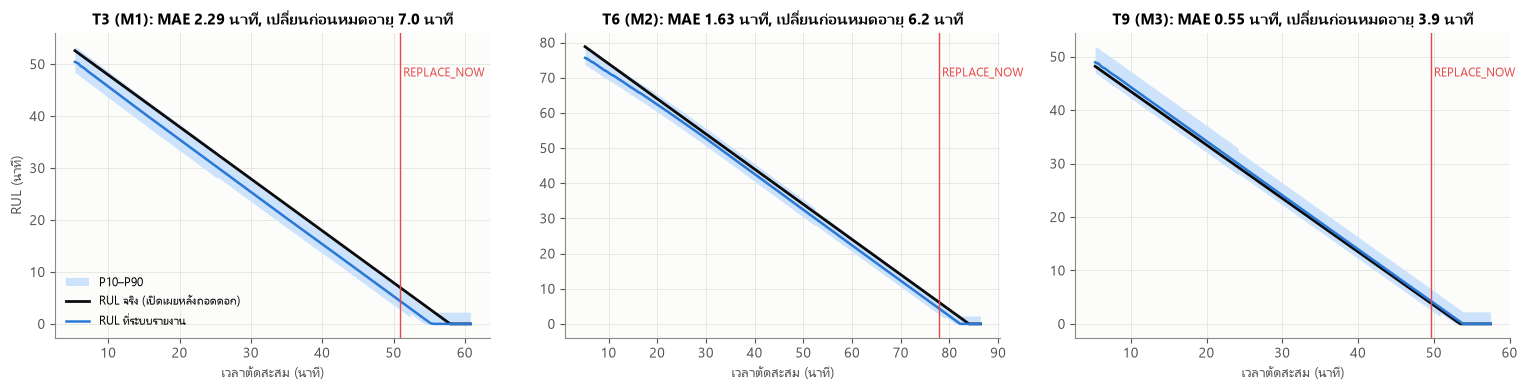

In [30]:
srep = pd.read_csv(RES / "stream_replay_per_run.csv"); ssum = pd.read_csv(RES / "stream_replay_summary.csv")
display(ssum.set_index("tool").round(2))
fig, axs = plt.subplots(1, 3, figsize=(15.5, 4))
for ax, t in zip(axs, X.STREAM_TOOLS):
    g = srep[(srep.tool == t) & (srep.phase == "MONITOR")]
    ax.fill_between(g.t_min, g.rul_lo, g.rul_hi, color=C["band"], lw=0, label="P10–P90")
    ax.plot(g.t_min, g.rul_true, color=C["ink"], lw=2, label="RUL จริง (เปิดเผยหลังถอดดอก)")
    ax.plot(g.t_min, g.rul, color=C["blue"], label="RUL ที่ระบบรายงาน")
    r_ = ssum[ssum.tool == t].iloc[0]
    ax.axvline(r_.t_replace, color=C["red"], lw=1); ax.text(r_.t_replace, ax.get_ylim()[1] * 0.85, " REPLACE_NOW", color=C["red"], fontsize=8.5)
    ax.set(title=f"T{t} (M{int(r_.machine)}): MAE {r_.MAE_all:.2f} นาที, เปลี่ยนก่อนหมดอายุ {r_.margin_min:.1f} นาที", xlabel="เวลาตัดสะสม (นาที)")
axs[0].set_ylabel("RUL (นาที)"); axs[0].legend(fontsize=8.5)
fig.tight_layout(); savefig(fig, "r08_heldout_stream"); plt.show()

## 6.3 สถาปัตยกรรมในระบบจริง
```mermaid
flowchart LR
  subgraph Offline["Offline (timeseries_docs/tool_rul_forecast)"]
    A[run_features.csv\n(9 ดอก)] --> B[experiments_rul.py\nnested selection + LOTO]
    B --> C[tool_rul_model.npz/json]
  end
  C -->|publish_tool_rul_model.py| M[(MinIO\nmodels/tool-rul/&lt;ver&gt;)]
  subgraph Backend["FastAPI backend"]
    R[registry: ดึงจาก MinIO\nตรวจ sha256 + self-test] --> S
    H[(LUH .h5\nT3/T6/T9 เท่านั้น)] --> S[streamer: เล่นตามเวลาจริง\nสกัดฟีเจอร์ทุกรัน]
    S --> P[runtime: causal filter → GRU → EOLTracker]
    P --> AL[alarms / audit (Postgres)]
  end
  M --> R
  P -->|WebSocket + REST| W[React dashboard]
```
รายละเอียด API หน้าเว็บ และการทดสอบอยู่ในรายงาน (หัวข้อ 6.3–6.6)